# Tối Ưu Lịch Trình MTA

Pipeline: dữ liệu -> dự báo nhu cầu -> tối ưu lịch -> đánh giá queue.

Kịch bản chạy: `weekday_peak`, `weekend`, `rainy_day`.

Kết quả chính lưu tại `outputs/default/` và `outputs/default/ui_export/`.

## 1. Setup va imports

Khoi tao duong dan, tham so va thu vien can dung.

In [ ]:
import os
import json
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import sys
import importlib

# --- Cấu hình đường dẫn Kaggle Kernel (ưu tiên) + fallback local dev ---
KAGGLE_LIB_DIR = Path("/kaggle/input/datasets/tnguynthnh142/libmta")
KAGGLE_DATA_DIR = Path("/kaggle/input/datasets/tnguynthnh142/mta-subway-ny")
KAGGLE_SCHEDULE_DIR = Path("/kaggle/input/datasets/tnguynthnh142/schedule-subway")
KAGGLE_WORKING = Path("/kaggle/working")

ON_KAGGLE = KAGGLE_LIB_DIR.exists() or Path("/kaggle/input").exists()

if KAGGLE_LIB_DIR.exists():
    # Thư viện pipeline gốc nằm phẳng (flat) trong dataset libmta
    if str(KAGGLE_LIB_DIR) not in sys.path:
        sys.path.insert(0, str(KAGGLE_LIB_DIR))
    import single_route_pipeline as srp
    importlib.reload(srp)
    DATA_DIR = KAGGLE_DATA_DIR
    SCHEDULE_DIR = KAGGLE_SCHEDULE_DIR
    OUT_DIR = KAGGLE_WORKING / "outputs" / "default"
    NOTEBOOK_DIR = KAGGLE_WORKING
else:
    _cwd = Path(".").resolve()
    if (_cwd / "lib" / "single_route_pipeline.py").is_file():
        NOTEBOOK_DIR = _cwd
    elif (_cwd / "notebooks" / "lib" / "single_route_pipeline.py").is_file():
        NOTEBOOK_DIR = _cwd / "notebooks"
    else:
        raise ImportError(f"Cannot locate notebooks/lib from cwd={_cwd}")
    if str(NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(NOTEBOOK_DIR))
    import lib.single_route_pipeline as srp
    importlib.reload(srp)
    REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
    DATA_DIR = REPO_ROOT / "datasets"
    SCHEDULE_DIR = REPO_ROOT / "datasets" / "schedule_current"
    OUT_DIR = Path("outputs/default")

GPU_INFO = srp.configure_gpu(mixed_precision=True, memory_growth=True)
DEMAND_MODEL_TYPE = "blend"
USE_HISTGBM_BLEND = True
CV_USE_BLEND = True
TUNE_RESID_CLIP_ON_VAL = True
HISTGBM_BLEND_WEIGHT = None

OUT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = DATA_DIR / "train_manifest.json"
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE, encoding="utf-8") as f:
        train_manifest = json.load(f)
else:
    train_manifest = {}

_DEFAULT_PATHS = {
    "ridership": "ridership.csv",
    "routes_by_station_complex": "routes_by_station_complex.csv",
    "routes": "routes.csv",
    "factors_hourly": "factors_hourly.csv",
    "headway_by_route_hour": "headway_by_route_hour.csv",
    "factors_daily": "factors_daily.csv",
}

def data_path(key: str) -> Path:
    """Resolve path trong DATA_DIR (ridership bundle); không dùng cho GTFS."""
    paths_cfg = train_manifest.get("paths", {}) or {}
    name = paths_cfg.get(key, _DEFAULT_PATHS.get(key, key))
    return DATA_DIR / name

RIDERSHIP_FILE = data_path("ridership")
ROUTES_BY_COMPLEX_FILE = data_path("routes_by_station_complex")
FACTORS_HOURLY_FILE = data_path("factors_hourly")
FACTORS_MODE = "hourly"
FACTORS_JOIN_KEYS = ["date", "hour"]

_scope = train_manifest.get("scope", {})
OPT_HOURS_FALLBACK = _scope.get("hours", list(range(24)))
OPT_HOURS = list(OPT_HOURS_FALLBACK)
USE_GTFS_OPERATING_HOURS = True
MIN_GTFS_TRIPS_PER_HOUR = 1

OPT_ROUTE_MODE = _scope.get("route_mode", "headway")
DIRECTIONS = _scope.get("directions", [0, 1])
ROUTE_ALIASES = train_manifest.get("route_aliases", {"SIR": "SI"})
HEADWAY_SERVICE = "Weekday"

CHUNK_ROWS = 1_000_000
NN_EPOCHS_MAIN = 200
NN_EPOCHS_CV = 80
CV_SPLITS = 8
CV_SEASON_YEARS = 2
HOLDOUT_TEST_SEASON = "autumn"
HOLDOUT_TEST_YEAR = 2025
HOLDOUT_VAL_SEASON = "summer"
HOLDOUT_VAL_YEAR = 2025

USE_ROUTE_EMBEDDING = True
USE_LAG_FEATURES = True
LAG_FEATURE_COLS = ["log_lag_24h", "log_lag_168h", "log_rolling_7d"]
RESID_CLIP = (-0.4, 0.4)
RESID_CLIP_CANDIDATES = [0.35, 0.45, 0.55]
CV_BLEND_TUNE_FRAC = 0.15
PEAK_SAMPLE_WEIGHT = 2.0
NN_HIDDEN = (64, 32)
NN_DROPOUT = 0.25
USE_BATCH_NORM = True
# T4 15GB: batch lớn hơn; CPU/local giữ 32
NN_BATCH_SIZE = 512 if GPU_INFO.get("gpus") else 32
USE_PER_ROUTE_LAMBDA = True
LAMBDA_KNEE_FALLBACK = 100.0  # khi §5b Pareto thất bại hoặc chưa có λ knee
COST_PER_VEHICLE_HOUR = 150.0  # optional $ display: fleet_cost = VH × rate
LAMBDA_GRID = [100, 150, 200, 400, 600, 1000]

RAINY_HOUR_BOOST: dict[int, float] = {
    17: 1.18, 18: 1.22, 19: 1.18, 8: 1.10, 9: 1.10,
}

TRIPS_MIN_FACTOR = 0.5
TRIPS_OVERNIGHT_MIN_FACTOR = 0.32
TRIPS_DAYTIME_MAX_FACTOR = 1.25   # ràng buộc TRIPS_MAX thống nhất ban ngày (07–22)
TRIPS_OVERNIGHT_MAX_FACTOR = 1.05
TRIPS_MAX_DELTA = 3
# Headway → trips bounds (single source of truth, merged with dynamic baseline bounds in §5)
MIN_HEADWAY_MIN = 3.0    # peak subway ~2–3 min (NYC)
MAX_HEADWAY_MIN = 20.0   # off-peak upper headway
OVERNIGHT_MAX_HEADWAY_MIN = 30.0
TURNAROUND_BUFFER_MIN = 5.0  # terminal dwell each end (MTA ops ~3–5 min; no GTFS field)
MAX_OVERFLOW_PCT = 1.0   # capacity floor target
SMOOTHNESS_MAX_DELTA = TRIPS_MAX_DELTA
USE_ANALYTICAL_OPT = True   # full 29 routes: analytical
RAINY_PEAK_TRIPS_MIN_FACTOR = 0.62
RAINY_DAYTIME_MAX_FACTOR = 1.42

# --- Station-level demand forecasting (thực thể dự báo = GA độc lập) ---
USE_STATION_EMBEDDING = True
STATION_EMBEDDING_DIM = 12          # ga nhiều hơn route → embedding rộng hơn
MIN_STATION_DEMAND_ROWS = 50        # ga cần ≥ N bản ghi để vào tập huấn luyện
STATION_STOP_MAX_DIST_KM = 1.5      # ngưỡng nối station_complex ↔ stop GTFS (toạ độ)

# --- Departure-Time Projection (Chiếu ngược Không – Thời gian) ---
BOARD_MINUTE = 30.0                 # phút đại diện trong giờ quẹt thẻ (giữa giờ)
RUN_DELAY_BUFFER_MIN = 0.0          # đệm trễ chạy tàu lịch sử cộng thêm vào T_travel

# --- Overnight demand detection (phân vị cầu thấp → ràng buộc đêm) ---
OVERNIGHT_DEMAND_PERCENTILE = 20.0  # ≤ phân vị này → overnight (cầu rất thấp)

# OPT_TARGET / LAMBDA_OPT / USE_PARETO_KNEE_LAMBDA / LAMBDA_CANDIDATES — replaced by lambda_knee_per_route (§5b_per_route)

# Quantile GBM cho scenario rủi ro (conservative demand)
RISK_SCENARIOS = ("rainy_day",)
RISK_DEMAND_QUANTILE = 0.75

PARETO_N_POINTS = 20

PEAK_HOURS = (7, 8, 9, 17, 18, 19)

HOURLY_FACTOR_COLS = [
    "temperature_c", "apparent_temperature_c",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "windspeed_kmh", "windgusts_kmh",
    "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]


print("TensorFlow:", tf.__version__)
print(f"Môi trường: {'Kaggle' if ON_KAGGLE else 'local'} | GPU: {GPU_INFO.get('gpus') or 'CPU'} "
      f"| mixed_precision={GPU_INFO.get('mixed_precision')} memory_growth={GPU_INFO.get('memory_growth')}")
print(f"Demand model: {DEMAND_MODEL_TYPE} (MLP + HistGBM) | batch_size={NN_BATCH_SIZE}")
print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
for label, p in [
    ("ridership", RIDERSHIP_FILE),
    ("routes_by_station_complex", ROUTES_BY_COMPLEX_FILE),
    ("factors_hourly", FACTORS_HOURLY_FILE),
    ("schedule", SCHEDULE_DIR),
]:
    print(f"  {label}: {'OK' if p.exists() else 'MISSING'} — {p.name if p.is_file() else p}")



2026-06-24 10:42:58.642795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782297778.896932      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782297778.976433      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782297779.557836      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782297779.557871      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782297779.557874      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Môi trường: Kaggle | GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1'] | mixed_precision=True memory_growth=True
Demand model: blend (MLP + HistGBM) | batch_size=512
Data dir: /kaggle/input/datasets/tnguynthnh142/mta-subway-ny
Output dir: /kaggle/working/outputs/default
  ridership: OK — ridership.csv
  routes_by_station_complex: OK — routes_by_station_complex.csv
  factors_hourly: OK — factors_hourly.csv
  schedule: OK — /kaggle/input/datasets/tnguynthnh142/schedule-subway


## 2. Nap va gop du lieu

Nap 3 nguon du lieu: ridership, GTFS va thoi tiet.
Sau do gop theo `(date, hour)` de tao bo du lieu huan luyen.

In [2]:
routes_complex = pd.read_csv(ROUTES_BY_COMPLEX_FILE)
routes_complex["station_complex_id"] = routes_complex["station_complex_id"].astype(str)

route_col = "gtfs_route_ids" if "gtfs_route_ids" in routes_complex.columns else "route_ids_gtfs"
station_to_routes = (
    routes_complex.assign(route=routes_complex[route_col].astype(str).str.split())
    .explode("route")
    .dropna(subset=["route"])
)
station_to_routes = station_to_routes[station_to_routes["route"] != ""]
station_to_routes = station_to_routes[["station_complex_id", "route"]].drop_duplicates()
station_to_routes["route"] = station_to_routes["route"].replace(ROUTE_ALIASES)

print("Tổng map station→route:", len(station_to_routes))
print("Số ga có map:", station_to_routes["station_complex_id"].nunique())
print("Số tuyến xuất hiện:", station_to_routes["route"].nunique())


Tổng map station→route: 767
Số ga có map: 445
Số tuyến xuất hiện: 26


In [3]:
usecols = ["transit_timestamp", "transit_mode", "station_complex_id", "ridership", "latitude", "longitude"]
valid_stations = set(station_to_routes["station_complex_id"].unique())

agg_parts = []
coord_parts = []
for chunk in pd.read_csv(
    RIDERSHIP_FILE,
    usecols=usecols,
    chunksize=CHUNK_ROWS,
    parse_dates=["transit_timestamp"],
    dtype={"station_complex_id": str},
):
    chunk = chunk[chunk["transit_mode"] == "subway"]
    chunk = chunk[chunk["station_complex_id"].isin(valid_stations)]
    if chunk.empty:
        continue
    chunk["date"] = chunk["transit_timestamp"].dt.date
    chunk["hour"] = chunk["transit_timestamp"].dt.hour
    grp = (
        chunk.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
        .sum()
    )
    agg_parts.append(grp)
    coord_parts.append(
        chunk[["station_complex_id", "latitude", "longitude"]].dropna().drop_duplicates("station_complex_id")
    )

# Lượng quẹt thẻ VÀO ga (boarding) theo (ga, ngày, giờ) — thực thể dự báo cấp ga
ridership_station = pd.concat(agg_parts, ignore_index=True)
# Toạ độ đại diện mỗi ga (nối station_complex ↔ stop GTFS cho Departure-Time Projection)
station_coords = (
    pd.concat(coord_parts, ignore_index=True)
    .drop_duplicates("station_complex_id")
    .reset_index(drop=True)
)
print(f"Aggregated (station,date,hour) rows: {len(ridership_station):,}")
print(f"Station coords: {len(station_coords):,} ga")
print("Date range:", ridership_station["date"].min(), "→", ridership_station["date"].max())


Aggregated (station,date,hour) rows: 7,294,700
Station coords: 424 ga
Date range: 2023-12-01 → 2025-11-30


In [4]:
# Lượng quẹt thẻ VÀO ga (boarding) — dự báo TRỰC TIẾP ở cấp GA, không gộp lên route
ridership_station = (
    ridership_station.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
    .sum()
    .rename(columns={"ridership": "demand"})
)

# --- GTFS structures cho Departure-Time Projection ---
headway = srp.build_headway_from_gtfs(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)
headway["route_id"] = headway["route_id"].astype(str)

# (1) Ma trận TRỌNG SỐ TẦN SUẤT: phân bổ cầu ga → cặp (route, direction) theo số chuyến GTFS
station_rd_weights = srp.build_station_route_direction_weights(
    station_to_routes, headway,
    min_trips=MIN_GTFS_TRIPS_PER_HOUR, route_aliases=ROUTE_ALIASES,
)

# (2) Ma trận THỜI GIAN HÀNH TRÌNH T_travel(route, dir, ga): offset GTFS bến đầu → ga thành phần
offset_templates = srp.load_gtfs_stop_offset_templates(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)
stops_gtfs = pd.read_csv(SCHEDULE_DIR / "stops.txt", dtype=str)
station_stop_map = srp.build_station_stop_map(
    station_coords, stops_gtfs, max_dist_km=STATION_STOP_MAX_DIST_KM,
)
travel_offsets = srp.build_station_travel_offsets(
    offset_templates, station_stop_map, run_delay_min=RUN_DELAY_BUFFER_MIN,
)

print(f"Station demand (ga×ngày×giờ) rows: {len(ridership_station):,} | "
      f"{ridership_station['station_complex_id'].nunique()} ga")
print(f"Trọng số tần suất ga×route×dir×giờ: {len(station_rd_weights):,} dòng")
print(f"Station↔stop map: {len(station_stop_map):,}/{station_coords['station_complex_id'].nunique()} ga "
      f"(dist median={station_stop_map['dist_km'].median():.3f} km)")
print(f"T_travel matrix (ga×route×dir): {len(travel_offsets):,} dòng, "
      f"median={travel_offsets['travel_offset_min'].median():.1f} phút")
headway.to_csv(OUT_DIR / "headway_by_route_hour_derived.csv", index=False)

Station demand (ga×ngày×giờ) rows: 7,275,945 | 424 ga
Trọng số tần suất ga×route×dir×giờ: 34,506 dòng
Station↔stop map: 424/424 ga (dist median=0.000 km)
T_travel matrix (ga×route×dir): 1,742 dòng, median=30.4 phút


In [5]:
def load_factors_hourly(path: Path) -> pd.DataFrame:
    """Load hourly weather/calendar; one row per (date, hour)."""
    fh = pd.read_csv(path, parse_dates=["timestamp", "date"])
    if "hour" not in fh.columns:
        fh["hour"] = fh["timestamp"].dt.hour
    keep = [
        "date", "hour", "day_of_week", "is_weekend", "is_us_holiday", "month",
        "temperature_c", "apparent_temperature_c",
        "precipitation_mm", "rain_mm", "snowfall_cm",
        "windspeed_kmh", "windgusts_kmh",
        "is_rain", "is_snow", "is_severe_wind",
        "is_major_event_window",
    ]
    keep = [c for c in keep if c in fh.columns]
    fh = fh[keep].drop_duplicates(subset=["date", "hour"]).copy()
    fh["date"] = pd.to_datetime(fh["date"]).dt.normalize()
    fh["hour"] = fh["hour"].astype(int)
    return fh


factors = load_factors_hourly(FACTORS_HOURLY_FILE)
print("Factors: hourly", factors.shape, "| cols:", len(factors.columns))


Factors: hourly (17543, 17) | cols: 17


In [6]:
ridership_station["date"] = pd.to_datetime(ridership_station["date"]).dt.normalize()
ridership_station["hour"] = ridership_station["hour"].astype(int)


ridership_all = ridership_station.merge(factors, on=FACTORS_JOIN_KEYS, how="left")
if "day_of_week" in ridership_all.columns:
    ridership_all["day_of_week"] = ridership_all["day_of_week"].fillna(
        ridership_all["date"].dt.dayofweek
    )
else:
    ridership_all["day_of_week"] = ridership_all["date"].dt.dayofweek
if "is_weekend" in ridership_all.columns:
    ridership_all["is_weekend"] = ridership_all["is_weekend"].fillna(
        (ridership_all["date"].dt.dayofweek >= 5).astype(int)
    )
else:
    ridership_all["is_weekend"] = (ridership_all["date"].dt.dayofweek >= 5).astype(int)
miss = ridership_all["is_rain"].isna().mean() if "is_rain" in ridership_all.columns else 1.0
print(f"Merge hourly on {FACTORS_JOIN_KEYS}: missing weather rows = {miss:.2%}")

flag_cols = [
    "is_us_holiday", "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]
num_cols = [c for c in HOURLY_FACTOR_COLS if c not in flag_cols]

for c in num_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0.0
    ridership_all[c] = ridership_all[c].fillna(ridership_all[c].median())
for c in flag_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0
    ridership_all[c] = ridership_all[c].fillna(0).astype(int)

print("Merged ridership shape:", ridership_all.shape)
print("Hours:", sorted(ridership_all["hour"].unique()))


Merge hourly on ['date', 'hour']: missing weather rows = 0.01%
Merged ridership shape: (7275945, 19)
Hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 3. EDA va chon scope

Kiem tra phan bo du lieu va mau nhu cau theo gio.
Tu ket qua EDA, chon `OPT_ROUTES` va tap slot toi uu `(route x direction x hour)`.

In [7]:
HEADWAY_ROUTES = sorted(headway["route_id"].astype(str).unique())

# Tuyến "có ridership" = tuyến phục vụ ≥1 ga có dữ liệu quẹt thẻ (qua ma trận tần suất)
active_stations = set(ridership_all["station_complex_id"].astype(str).unique())
_route_station_cnt = (
    station_rd_weights[station_rd_weights["station_complex_id"].isin(active_stations)]
    .groupby("route")["station_complex_id"].nunique()
)
RIDERSHIP_ROUTES = _route_station_cnt[_route_station_cnt >= 1].index.astype(str).tolist()

if OPT_ROUTE_MODE == "headway":
    OPT_ROUTES = HEADWAY_ROUTES
elif OPT_ROUTE_MODE == "intersection":
    OPT_ROUTES = sorted(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES))
else:
    OPT_ROUTES = RIDERSHIP_ROUTES

EXCLUDED_NO_RIDERSHIP = [r for r in OPT_ROUTES if r not in set(RIDERSHIP_ROUTES)]
OPT_ROUTES = [r for r in OPT_ROUTES if r in set(RIDERSHIP_ROUTES)]
if EXCLUDED_NO_RIDERSHIP:
    print(f"Loại {len(EXCLUDED_NO_RIDERSHIP)} tuyến không có ridership: {EXCLUDED_NO_RIDERSHIP}")

# Route demand proxy (chỉ EDA/heatmap): cầu ga × trọng số tần suất → tổng theo route
_station_hour = ridership_all.groupby(["station_complex_id", "hour"], as_index=False)["demand"].mean()
route_totals = (
    _station_hour.merge(
        station_rd_weights[["station_complex_id", "route", "hour", "alloc_weight"]],
        on=["station_complex_id", "hour"],
    )
    .assign(_d=lambda x: x["demand"] * x["alloc_weight"])
    .groupby("route")["_d"].sum().sort_values(ascending=False)
)
route_totals = route_totals[route_totals.index.isin(OPT_ROUTES)]
print("Top 12 tuyến theo cầu (proxy chiếu từ ga):")
print(route_totals.head(12).round(0))
print()
print(f"OPT_ROUTES ({len(OPT_ROUTES)} tuyến, mode={OPT_ROUTE_MODE}):", OPT_ROUTES[:8], "...")

route_hours = {r: list(OPT_HOURS_FALLBACK) for r in OPT_ROUTES}
route_dir_hours: dict[tuple[str, int], list[int]] = {}
if USE_GTFS_OPERATING_HOURS:
    route_dir_hours = srp.derive_operating_hours_by_route_direction(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    route_hours = srp.derive_operating_hours_by_route(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    empty = [k for k, hs in route_dir_hours.items() if not hs]
    if empty:
        raise ValueError(f"Không có giờ GTFS cho: {empty[:8]}")
    OPT_HOURS = sorted({h for hs in route_dir_hours.values() for h in hs})
    print(f"GTFS operating hours (route×dir): {len(route_dir_hours)} keys, union {len(OPT_HOURS)} hours")
    lens = [len(hs) for hs in route_dir_hours.values()]
    print(f"  hours per route×dir: min={min(lens)}, max={max(lens)}")

OPT_SCOPE = [
    (r, d, h) for r in OPT_ROUTES for d in DIRECTIONS
    for h in (route_dir_hours.get((r, d)) or route_hours.get(r, OPT_HOURS_FALLBACK))
]
print(f"OPT_SCOPE slots (route×dir×giờ xuất bến): {len(OPT_SCOPE)}")

# Tập GA huấn luyện = ga phục vụ OPT_ROUTES & đủ số bản ghi
scope_stations = set(
    station_rd_weights.loc[station_rd_weights["route"].isin(OPT_ROUTES), "station_complex_id"]
) & active_stations
station_row_counts = ridership_all.groupby("station_complex_id").size()
OPT_STATIONS = sorted(
    s for s in scope_stations if int(station_row_counts.get(s, 0)) >= MIN_STATION_DEMAND_ROWS
)

# Dataset NN cấp GA (giữ toàn bộ giờ ga có dữ liệu — projection xử lý ánh xạ giờ→xuất bến)
df = ridership_all[ridership_all["station_complex_id"].isin(OPT_STATIONS)].copy()
print()
print(f"Dataset NN (station-level): {len(df):,} bản ghi, "
      f"{df['date'].nunique()} ngày, {len(OPT_STATIONS)} ga, routes phục vụ={len(OPT_ROUTES)}")
print(f"Demand range (boarding/ga/giờ): {df['demand'].min():.0f} – {df['demand'].max():.0f}")
MISSING_RIDERSHIP_ROUTES = list(EXCLUDED_NO_RIDERSHIP)
print(f"Tuyến đã loại khỏi pipeline (không ridership): {MISSING_RIDERSHIP_ROUTES or []}")


Loại 4 tuyến không có ridership: ['6X', '7X', 'FX', 'SI']
Top 12 tuyến theo cầu (proxy chiếu từ ga):
route
1    298182.0
6    270595.0
7    253166.0
F    223280.0
R    206968.0
A    171973.0
E    167702.0
Q    161944.0
L    159626.0
M    151267.0
2    148037.0
4    147304.0
Name: _d, dtype: float64

OPT_ROUTES (25 tuyến, mode=headway): ['1', '2', '3', '4', '5', '6', '7', 'A'] ...
GTFS operating hours (route×dir): 50 keys, union 24 hours
  hours per route×dir: min=2, max=24
OPT_SCOPE slots (route×dir×giờ xuất bến): 1104

Dataset NN (station-level): 7,275,945 bản ghi, 731 ngày, 424 ga, routes phục vụ=25
Demand range (boarding/ga/giờ): 1 – 23060
Tuyến đã loại khỏi pipeline (không ridership): ['6X', '7X', 'FX', 'SI']


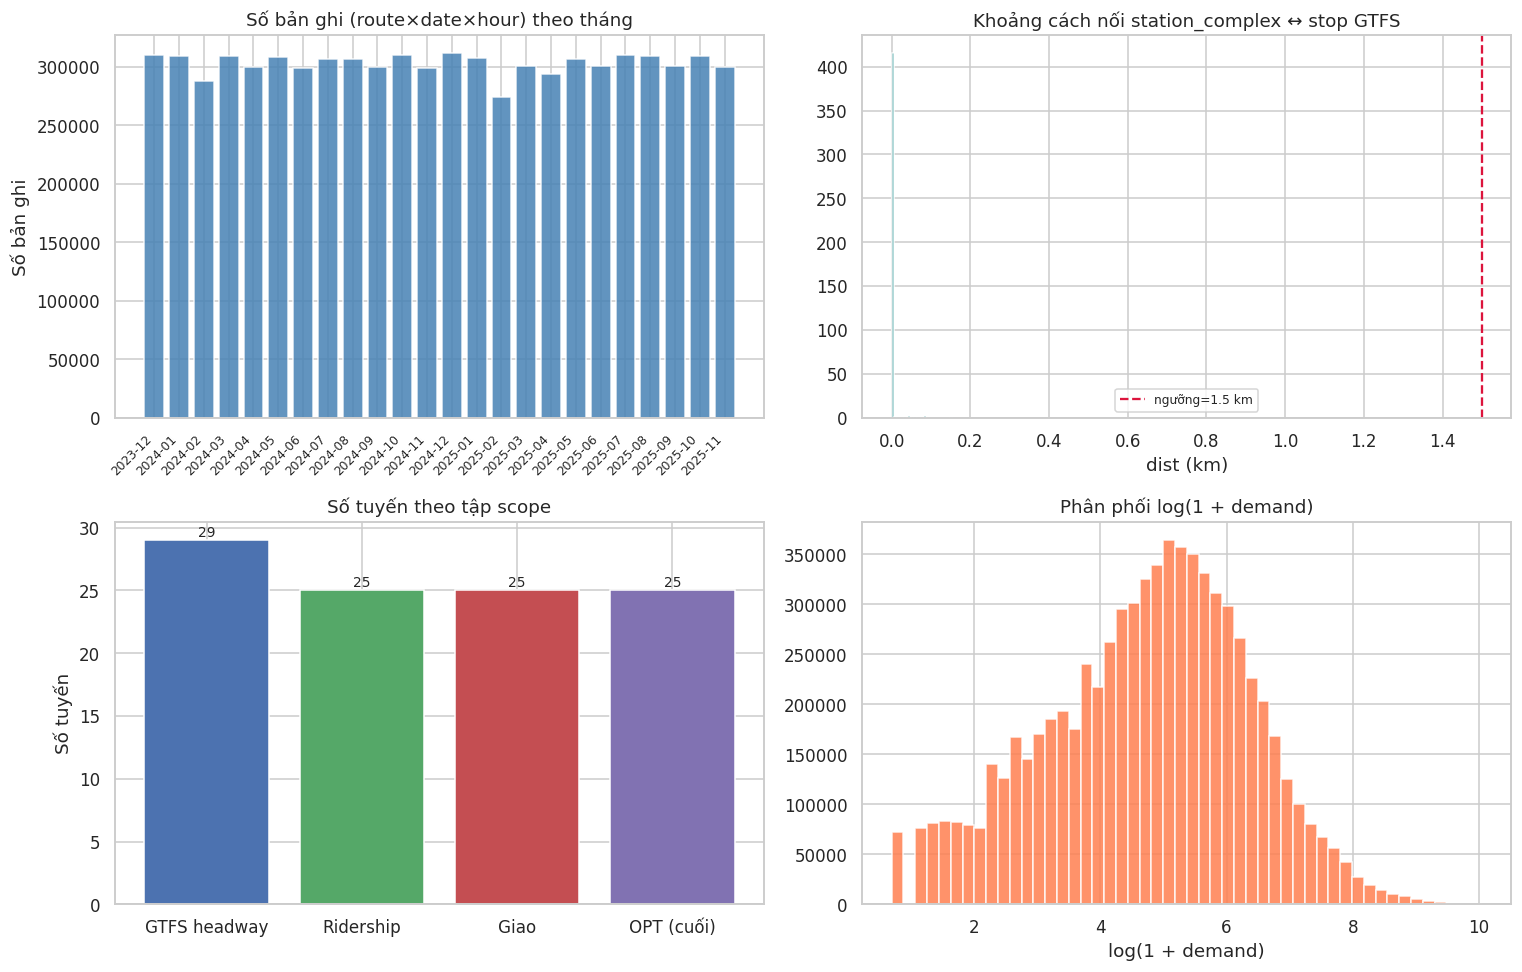

Thống kê demand (toàn bộ ridership_all):
count    7275945.0
mean         342.3
std          722.6
min            1.0
25%           37.0
50%          131.0
75%          355.0
max        23060.0


In [8]:
# --- EDA: Tổng quan dữ liệu ---
monthly = ridership_all.copy()
monthly["month"] = monthly["date"].dt.to_period("M").astype(str)
monthly_cnt = monthly.groupby("month").size()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(range(len(monthly_cnt)), monthly_cnt.values, color="steelblue", alpha=0.85)
axes[0, 0].set_xticks(range(len(monthly_cnt)))
axes[0, 0].set_xticklabels(monthly_cnt.index, rotation=45, ha="right", fontsize=8)
axes[0, 0].set_title("Số bản ghi (route×date×hour) theo tháng")
axes[0, 0].set_ylabel("Số bản ghi")

if "dist_km" in station_stop_map.columns and len(station_stop_map):
    dist = station_stop_map["dist_km"].dropna()
    axes[0, 1].hist(dist, bins=30, color="teal", edgecolor="white", alpha=0.85)
    axes[0, 1].axvline(STATION_STOP_MAX_DIST_KM, color="crimson", ls="--",
                       label=f"ngưỡng={STATION_STOP_MAX_DIST_KM} km")
    axes[0, 1].set_title("Khoảng cách nối station_complex ↔ stop GTFS")
    axes[0, 1].set_xlabel("dist (km)")
    axes[0, 1].legend(fontsize=8)
else:
    axes[0, 1].set_axis_off()

route_sets = {
    "GTFS headway": len(HEADWAY_ROUTES),
    "Ridership": len(RIDERSHIP_ROUTES),
    "Giao": len(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES)),
    "OPT (cuối)": len(OPT_ROUTES),
}
axes[1, 0].bar(
    route_sets.keys(), route_sets.values(),
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
)
axes[1, 0].set_title("Số tuyến theo tập scope")
axes[1, 0].set_ylabel("Số tuyến")
for i, v in enumerate(route_sets.values()):
    axes[1, 0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

log_d = np.log1p(ridership_all["demand"].clip(lower=0))
axes[1, 1].hist(log_d, bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1, 1].set_title("Phân phối log(1 + demand)")
axes[1, 1].set_xlabel("log(1 + demand)")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()

print("Thống kê demand (toàn bộ ridership_all):")
print(ridership_all["demand"].describe().round(1).to_string())

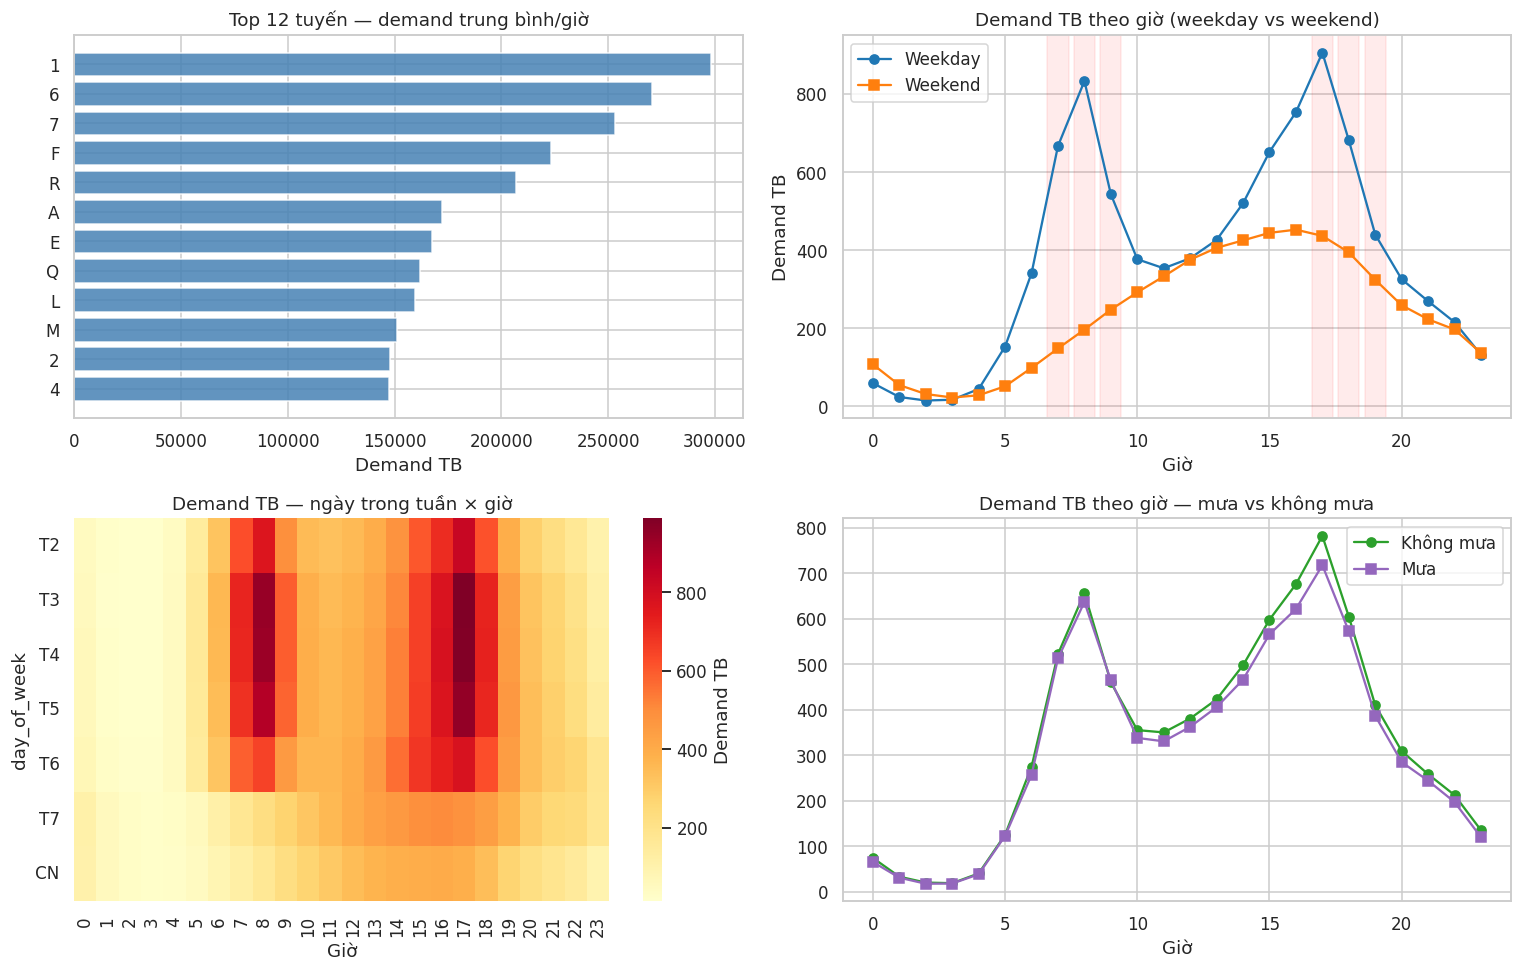

In [9]:
# --- EDA: Mẫu nhu cầu theo giờ & tuyến ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

top12 = route_totals.head(12)
axes[0, 0].barh(top12.index[::-1], top12.values[::-1], color="steelblue", alpha=0.85)
axes[0, 0].set_title("Top 12 tuyến — demand trung bình/giờ")
axes[0, 0].set_xlabel("Demand TB")

hourly_wd = ridership_all.loc[ridership_all["is_weekend"] == 0].groupby("hour")["demand"].mean()
hourly_we = ridership_all.loc[ridership_all["is_weekend"] == 1].groupby("hour")["demand"].mean()
hrs = sorted(ridership_all["hour"].unique())
axes[0, 1].plot(hrs, [hourly_wd.get(h, np.nan) for h in hrs], "o-", label="Weekday", color="#1f77b4")
axes[0, 1].plot(hrs, [hourly_we.get(h, np.nan) for h in hrs], "s-", label="Weekend", color="#ff7f0e")
for ph in PEAK_HOURS:
    axes[0, 1].axvspan(ph - 0.4, ph + 0.4, alpha=0.08, color="red")
axes[0, 1].set_title("Demand TB theo giờ (weekday vs weekend)")
axes[0, 1].set_xlabel("Giờ")
axes[0, 1].set_ylabel("Demand TB")
axes[0, 1].legend()

pivot_dow = (
    ridership_all.groupby(["day_of_week", "hour"])["demand"].mean().unstack(fill_value=0)
)
sns.heatmap(pivot_dow, cmap="YlOrRd", ax=axes[1, 0], cbar_kws={"label": "Demand TB"})
dow_labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
axes[1, 0].set_yticklabels(
    [dow_labels[int(i)] if int(i) < len(dow_labels) else str(i) for i in pivot_dow.index],
    rotation=0,
)
axes[1, 0].set_title("Demand TB — ngày trong tuần × giờ")
axes[1, 0].set_xlabel("Giờ")

if "is_rain" in ridership_all.columns:
    rain_cmp = ridership_all.groupby(["hour", "is_rain"])["demand"].mean().unstack(fill_value=np.nan)
    if 0 in rain_cmp.columns and 1 in rain_cmp.columns:
        axes[1, 1].plot(rain_cmp.index, rain_cmp[0], "o-", label="Không mưa", color="#2ca02c")
        axes[1, 1].plot(rain_cmp.index, rain_cmp[1], "s-", label="Mưa", color="#9467bd")
        axes[1, 1].set_title("Demand TB theo giờ — mưa vs không mưa")
        axes[1, 1].set_xlabel("Giờ")
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, "Không đủ nhãn mưa", ha="center", va="center", transform=axes[1, 1].transAxes)
        axes[1, 1].set_axis_off()
else:
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_demand_patterns.png", dpi=120, bbox_inches="tight")
plt.show()

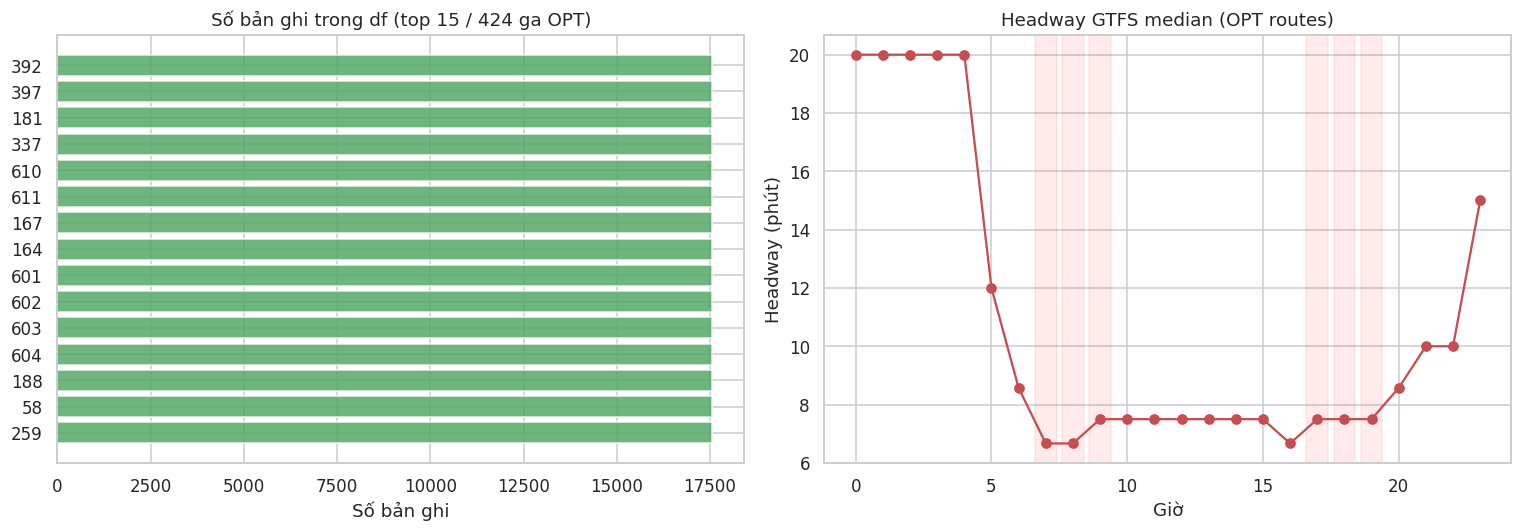

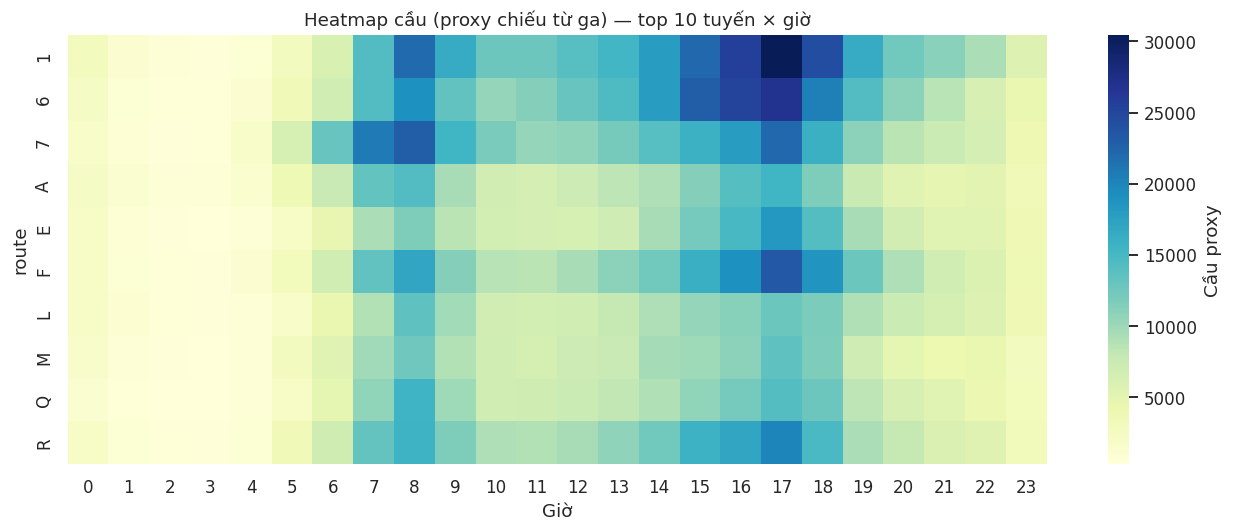

Đã lưu EDA figures vào /kaggle/working/outputs/default


In [10]:
# --- EDA: Scope tối ưu, headway GTFS & heatmap tuyến×giờ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

station_counts_df = df.groupby("station_complex_id").size().sort_values(ascending=False).head(15)
axes[0].barh(station_counts_df.index[::-1].astype(str), station_counts_df.values[::-1], color="#55A868", alpha=0.85)
axes[0].set_title(f"Số bản ghi trong df (top 15 / {len(OPT_STATIONS)} ga OPT)")
axes[0].set_xlabel("Số bản ghi")

if not headway.empty and "avg_headway_min" in headway.columns:
    hw = headway[headway["route_id"].astype(str).isin(OPT_ROUTES)].copy()
    hw_med = hw.groupby("hour")["avg_headway_min"].median()
    axes[1].plot(hw_med.index, hw_med.values, "o-", color="#C44E52")
    for ph in PEAK_HOURS:
        axes[1].axvspan(ph - 0.4, ph + 0.4, alpha=0.08, color="red")
    axes[1].set_title("Headway GTFS median (OPT routes)")
    axes[1].set_xlabel("Giờ")
    axes[1].set_ylabel("Headway (phút)")
else:
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_scope_headway.png", dpi=120, bbox_inches="tight")
plt.show()

top_routes_heatmap = route_totals.head(10).index.tolist()
hm_data = (
    _station_hour.merge(
        station_rd_weights[["station_complex_id", "route", "hour", "alloc_weight"]],
        on=["station_complex_id", "hour"],
    )
    .assign(_d=lambda x: x["demand"] * x["alloc_weight"])
    .query("route in @top_routes_heatmap")
    .groupby(["route", "hour"])["_d"].sum()
    .unstack(fill_value=0)
)
fig2, ax2 = plt.subplots(figsize=(12, 5))
sns.heatmap(hm_data, cmap="YlGnBu", ax=ax2, cbar_kws={"label": "Cầu proxy"})
ax2.set_title("Heatmap cầu (proxy chiếu từ ga) — top 10 tuyến × giờ")
ax2.set_xlabel("Giờ")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_route_hour_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Đã lưu EDA figures vào {OUT_DIR.resolve()}")

## 4. Huan luyen demand model

Dung hold-out `autumn_2025`.
Mo hinh ket hop MLP + HistGBM de du bao demand theo ga.

In [11]:
df = df.sort_values(["station_complex_id", "date", "hour"]).reset_index(drop=True)

if "month" not in df.columns:
    df["month"] = df["date"].dt.month

df = srp.add_cyclical_time_features(df)

# Thực thể có embedding = GA (station). Input Keras vẫn tên 'route_idx' để tương thích artifact;
# 'route_to_idx' giữ nguyên tên biến nhưng ánh xạ station_complex_id → chỉ số embedding.
station_to_idx = {s: i for i, s in enumerate(OPT_STATIONS)}
df["station_idx"] = df["station_complex_id"].map(station_to_idx).astype(int)
df["route_idx"] = df["station_idx"]
route_to_idx = station_to_idx

df = srp.add_lag_features(
    df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id"
)

unique_dates = sorted(df["date"].unique())
n_dates = len(unique_dates)

train_dates, val_dates, test_dates, holdout_meta = srp.build_seasonal_holdout_splits(
    unique_dates,
    test_season=HOLDOUT_TEST_SEASON,
    test_season_year=HOLDOUT_TEST_YEAR,
    val_season=HOLDOUT_VAL_SEASON,
    val_season_year=HOLDOUT_VAL_YEAR,
    auto_adjust=False,
    return_meta=True,
)
HOLDOUT_TEST_SEASON = holdout_meta["test_season"]
HOLDOUT_TEST_YEAR = holdout_meta["test_season_year"]
HOLDOUT_VAL_SEASON = holdout_meta["val_season"]
HOLDOUT_VAL_YEAR = holdout_meta["val_season_year"]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

# Baseline = median lượng boarding LỊCH SỬ tại CHÍNH ga đó (chu kỳ cục bộ theo giờ × ngày thường/cuối tuần)
baseline_lookup = (
    train_df.groupby(["station_complex_id", "hour", "is_weekend"])["demand"]
    .median()
    .rename("baseline_demand")
)
fallback = train_df.groupby(["station_complex_id", "hour"])["demand"].median().rename("fallback_demand")


def attach_baseline(d: pd.DataFrame) -> pd.DataFrame:
    d = d.merge(baseline_lookup, on=["station_complex_id", "hour", "is_weekend"], how="left")
    d = d.merge(fallback, on=["station_complex_id", "hour"], how="left")
    d["baseline_demand"] = d["baseline_demand"].fillna(d["fallback_demand"])
    return d.drop(columns=["fallback_demand"])


train_df = attach_baseline(train_df)
val_df   = attach_baseline(val_df)
test_df  = attach_baseline(test_df)

train_df = srp.fill_lag_from_train(train_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")
val_df   = srp.fill_lag_from_train(val_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")
test_df  = srp.fill_lag_from_train(test_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")

for part in (train_df, val_df, test_df):
    part["log_baseline"] = np.log1p(part["baseline_demand"])

NUM_FEATURES = srp.build_num_feature_list(
    HOURLY_FACTOR_COLS,
    use_lags=USE_LAG_FEATURES,
    lag_cols=LAG_FEATURE_COLS,
)
NUM_FEATURES = [c for c in NUM_FEATURES if c in train_df.columns]
print(f"NUM_FEATURES ({len(NUM_FEATURES)}):", NUM_FEATURES)

lag_feature_defaults = {}
if USE_LAG_FEATURES:
    lag_med = train_df.groupby(["station_complex_id", "hour"])[LAG_FEATURE_COLS].median()
    for (sid, hour), row in lag_med.iterrows():
        lag_feature_defaults[f"{sid}|{hour}"] = {c: float(row[c]) for c in LAG_FEATURE_COLS}

print(f"Hold-out theo mùa: test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}, "
      f"val={HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}")
print(f"{n_dates} ngày → train {len(train_dates)} / val {len(val_dates)} / test {len(test_dates)}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

y_train = np.log1p(train_df["demand"].values) - train_df["log_baseline"].values
y_val   = np.log1p(val_df["demand"].values) - val_df["log_baseline"].values
y_test  = np.log1p(test_df["demand"].values) - test_df["log_baseline"].values

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[NUM_FEATURES])
X_val_num   = scaler.transform(val_df[NUM_FEATURES])
X_test_num  = scaler.transform(test_df[NUM_FEATURES])
X_train_route = train_df["route_idx"].values.reshape(-1, 1)
X_val_route   = val_df["route_idx"].values.reshape(-1, 1)
X_test_route  = test_df["route_idx"].values.reshape(-1, 1)

print("Target (residual log demand) — train mean: {:.3f}, std: {:.3f}".format(
    y_train.mean(), y_train.std()))


NUM_FEATURES (23): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_us_holiday', 'temperature_c', 'apparent_temperature_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'windspeed_kmh', 'windgusts_kmh', 'is_rain', 'is_snow', 'is_severe_wind', 'is_major_event_window', 'log_baseline', 'log_lag_24h', 'log_lag_168h', 'log_rolling_7d']
Hold-out theo mùa: test=autumn_2025, val=summer_2025
731 ngày → train 548 / val 92 / test 91
Train: 5,444,220 | Val: 921,316 | Test: 910,409
Target (residual log demand) — train mean: -0.040, std: 0.400


In [12]:
histgbm_model = None
blend_weight_mlp = 0.5
blend_weight_tuned = False


def make_demand_model(n_entities: int, n_num_features: int) -> Model:
    """MLP residual log-demand với embedding GA (station-level)."""
    return srp.build_demand_model(
        n_entities,
        n_num_features,
        use_route_embedding=USE_STATION_EMBEDDING,
        embedding_dim=STATION_EMBEDDING_DIM,
        hidden=NN_HIDDEN,
        dropout=NN_DROPOUT,
        use_batch_norm=USE_BATCH_NORM,
    )


def _fit_inputs(route_idx, num_feat):
    return srp.format_keras_inputs(
        route_idx, num_feat, use_route_embedding=USE_ROUTE_EMBEDDING
    )


model = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
model.summary()


I0000 00:00:1782298000.593439      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782298000.599564      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ route_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_emb           │ (None, 1, 12)     │      5,088 │ route_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ route_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_features        │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ num_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 64)        │      2,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_0                │ (None, 64)        │        256 │ dense_0[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0 (Dropout) │ (None, 64)        │          0 │ bn_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_log_demand │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,889 (38.63 KB)

 Trainable params: 9,697 (37.88 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
train_weights = np.ones(len(train_df), dtype=float)
if PEAK_SAMPLE_WEIGHT > 1.0:
    peak_mask = train_df["hour"].isin(PEAK_HOURS)
    train_weights[peak_mask.to_numpy()] = PEAK_SAMPLE_WEIGHT
    print(f"Peak sample weight ×{PEAK_SAMPLE_WEIGHT}: {peak_mask.sum():,}/{len(train_df):,} rows")

early = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)

history = model.fit(
    _fit_inputs(X_train_route, X_train_num),
    y_train,
    validation_data=(_fit_inputs(X_val_route, X_val_num), y_val),
    sample_weight=train_weights,
    epochs=NN_EPOCHS_MAIN,
    batch_size=NN_BATCH_SIZE,
    verbose=0,
    callbacks=[early, lr_reduce],
)
print(f"Stop @ epoch {len(history.history['loss'])} | best val_mae={min(history.history.get('val_mae', history.history['loss'])):.4f}")

if USE_HISTGBM_BLEND:
    histgbm_model = srp.fit_histgbm_demand(X_train_num, y_train, sample_weight=train_weights)
    print("HistGBM (literature tree baseline) fitted.")


Peak sample weight ×2.0: 1,370,269/5,444,220 rows


I0000 00:00:1782298006.220468      73 service.cc:152] XLA service 0x7e3b0800e750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782298006.220541      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782298006.220548      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782298006.761631      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782298009.973293      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Stop @ epoch 128 | best val_mae=0.1796
HistGBM (literature tree baseline) fitted.


  val MAE @ clip ±0.35: 39.1
  val MAE @ clip ±0.45: 38.6
  val MAE @ clip ±0.55: 38.4
→ Chọn RESID_CLIP = ±0.55 (val MAE=38.4)
Blend val: MLP weight=0.80 (MAE=39.0)
=== Hold-out test ===
  blend | test=autumn_2025
  Baseline: MAE=67 RMSE=198 R²=+0.934 MAPE=19.5% SMAPE=25.0%
  Model:    MAE=43 RMSE=137 R²=+0.969 MAPE=12.7% SMAPE=19.0%  (ΔMAE +36.7%)


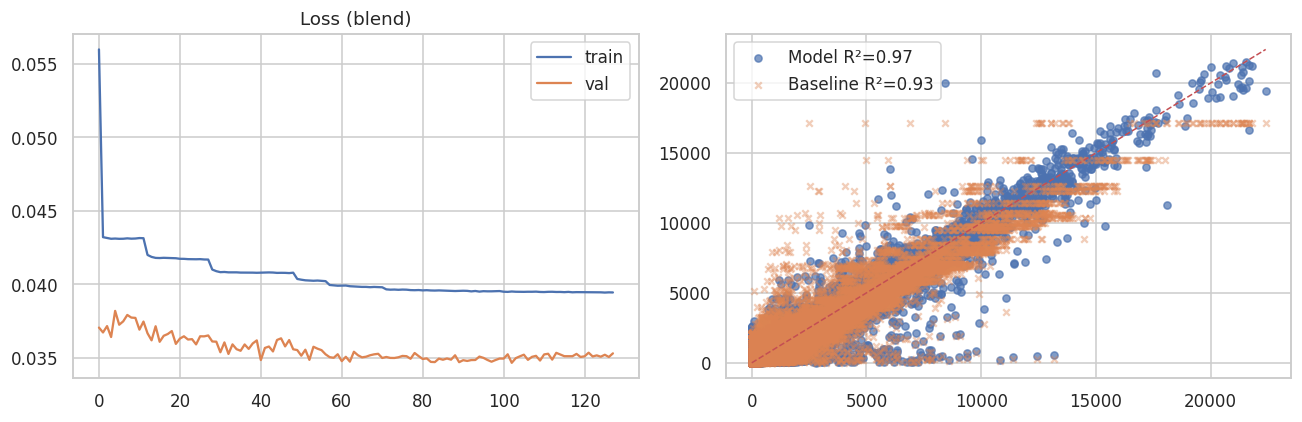

In [14]:
if TUNE_RESID_CLIP_ON_VAL:
    best_clip, best_mae = RESID_CLIP[1], float("inf")
    for clip_hi in RESID_CLIP_CANDIDATES:
        tmp_clip = (-clip_hi, clip_hi)
        pred_resid = model.predict(_fit_inputs(X_val_route, X_val_num), verbose=0).ravel()
        pred_resid = np.clip(pred_resid, *tmp_clip)
        pred_val = np.expm1(val_df["log_baseline"].values + pred_resid)
        mae_val = mean_absolute_error(val_df["demand"].values, pred_val)
        print(f"  val MAE @ clip ±{clip_hi:.2f}: {mae_val:,.1f}")
        if mae_val < best_mae:
            best_mae, best_clip = mae_val, clip_hi
    RESID_CLIP = (-best_clip, best_clip)
    print(f"→ Chọn RESID_CLIP = ±{best_clip:.2f} (val MAE={best_mae:,.1f})")


def _predict_resid_mlp(route_idx_arr, num_feat_arr):
    return model.predict(_fit_inputs(route_idx_arr, num_feat_arr), verbose=0).ravel()


blend_weight_tuned = False


def tune_blend_weight_mlp() -> None:
    """Chọn trọng số MLP/HistGBM trên val — chỉ chạy một lần."""
    global blend_weight_mlp, blend_weight_tuned
    if histgbm_model is None:
        return
    if blend_weight_tuned:
        return
    if HISTGBM_BLEND_WEIGHT is not None:
        blend_weight_mlp = float(HISTGBM_BLEND_WEIGHT)
        blend_weight_tuned = True
        return
    pred_mlp = np.clip(_predict_resid_mlp(X_val_route, X_val_num), *RESID_CLIP)
    pred_gbm = histgbm_model.predict(X_val_num)
    best_w, best_mae = 0.5, float("inf")
    for w in np.linspace(0.2, 0.8, 7):
        pr = srp.blend_residual_predictions(pred_mlp, pred_gbm, w)
        pv = srp.residuals_to_demand(val_df["log_baseline"].values, pr, RESID_CLIP)
        m = mean_absolute_error(val_df["demand"].values, pv)
        if m < best_mae:
            best_mae, best_w = m, w
    blend_weight_mlp = best_w
    blend_weight_tuned = True
    print(f"Blend val: MLP weight={blend_weight_mlp:.2f} (MAE={best_mae:,.1f})")


def predict_demand(route_idx_arr, num_feat_arr, log_baseline):
    pred_mlp = np.clip(_predict_resid_mlp(route_idx_arr, num_feat_arr), *RESID_CLIP)
    if histgbm_model is not None:
        pred_gbm = histgbm_model.predict(num_feat_arr)
        tune_blend_weight_mlp()
        pred_resid = srp.blend_residual_predictions(pred_mlp, pred_gbm, blend_weight_mlp)
    else:
        pred_resid = pred_mlp
    return srp.residuals_to_demand(log_baseline, pred_resid, RESID_CLIP)


y_pred = predict_demand(X_test_route, X_test_num, test_df["log_baseline"].values)

y_true = test_df["demand"].values
baseline_pred_test = test_df["baseline_demand"].values
m_base = srp.regression_metrics(y_true, baseline_pred_test)
m_nn = srp.regression_metrics(y_true, y_pred)
mae_impr = (m_base["mae"] - m_nn["mae"]) / m_base["mae"] * 100

nn_eval_metrics = {
    "holdout": {
        "test_block": f"{HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}",
        "val_block": f"{HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}",
        "n_test": int(len(test_df)),
        "model_type": DEMAND_MODEL_TYPE,
        "blend_mlp_weight": float(blend_weight_mlp) if histgbm_model is not None else None,
        "baseline": m_base,
        "model": m_nn,
        "mae_improvement_pct": float(mae_impr),
        "resid_clip": float(RESID_CLIP[1]),
    },
}

def _fmt(m):
    return f"MAE={m['mae']:,.0f} RMSE={m['rmse']:,.0f} R²={m['r2']:+.3f} MAPE={m['mape_pct']:.1f}% SMAPE={m['smape_pct']:.1f}%"

print("=== Hold-out test ===")
print(f"  {DEMAND_MODEL_TYPE} | test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}")
print(f"  Baseline: {_fmt(m_base)}")
print(f"  Model:    {_fmt(m_nn)}  (ΔMAE {mae_impr:+.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title(f"Loss ({DEMAND_MODEL_TYPE})")
axes[0].legend()
axes[1].scatter(y_true, y_pred, alpha=0.7, s=22, label=f"Model R²={m_nn['r2']:.2f}")
axes[1].scatter(y_true, baseline_pred_test, alpha=0.4, s=18, marker="x", label=f"Baseline R²={m_base['r2']:.2f}")
lim = max(y_true.max(), y_pred.max())
axes[1].plot([0, lim], [0, lim], "r--", lw=1)
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_nn_eval.png", dpi=120, bbox_inches="tight")
plt.show()



In [15]:
all_df = df.copy()
if "month" not in all_df.columns:
    all_df["month"] = all_df["date"].dt.month
all_df = srp.add_cyclical_time_features(all_df)
all_df = srp.add_lag_features(
    all_df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id"
)
all_df = attach_baseline(all_df)
all_df = srp.fill_lag_from_train(all_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")
all_df["log_baseline"] = np.log1p(all_df["baseline_demand"])

dates_arr = np.array(sorted(all_df["date"].unique()))
season_cv_folds = srp.build_season_year_cv_folds(dates_arr, n_years=CV_SEASON_YEARS)
if not season_cv_folds:
    raise ValueError("Không đủ dữ liệu cho CV mùa×năm — cần ít nhất một ngày mỗi (mùa, năm)")
print(f"CV theo mùa×năm: {len(season_cv_folds)} fold (kỳ vọng tối đa {CV_SPLITS})")

cv_mae_nn, cv_mae_base, cv_rmse_nn, cv_rmse_base, cv_r2_nn, cv_r2_base = [], [], [], [], [], []
for fold, (tr_dates, te_dates, fold_label) in enumerate(season_cv_folds):
    tr_d = all_df[all_df["date"].isin(tr_dates)].copy()
    te_d = all_df[all_df["date"].isin(te_dates)].copy()
    if len(tr_d) == 0 or len(te_d) == 0:
        continue

    bl_lookup = (
        tr_d.groupby(["station_complex_id", "hour", "is_weekend"])["demand"].median()
        .rename("baseline_demand_cv")
    )
    fb = tr_d.groupby(["station_complex_id", "hour"])["demand"].median().rename("fb_demand")
    te_d = te_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["station_complex_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["station_complex_id", "hour"], how="left")
    te_d["baseline_demand_cv"] = te_d["baseline_demand_cv"].fillna(te_d["fb_demand"])
    te_d = te_d.dropna(subset=["baseline_demand_cv"])
    te_d["log_baseline"] = np.log1p(te_d["baseline_demand_cv"])

    tr_d2 = tr_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["station_complex_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["station_complex_id", "hour"], how="left")
    tr_d2["baseline_demand_cv"] = tr_d2["baseline_demand_cv"].fillna(tr_d2["fb_demand"])
    tr_d2 = tr_d2.dropna(subset=["baseline_demand_cv"])
    tr_d2["log_baseline"] = np.log1p(tr_d2["baseline_demand_cv"])

    sc = StandardScaler()
    Xt = sc.fit_transform(tr_d2[NUM_FEATURES])
    Xe = sc.transform(te_d[NUM_FEATURES])
    yt = np.log1p(tr_d2["demand"].values) - tr_d2["log_baseline"].values
    ye = te_d["demand"].values

    w_cv = np.ones(len(tr_d2), dtype=float)
    if PEAK_SAMPLE_WEIGHT > 1.0:
        pk = tr_d2["hour"].isin(PEAK_HOURS)
        w_cv[pk.to_numpy()] = PEAK_SAMPLE_WEIGHT

    sorted_tr = sorted(tr_dates)
    n_tune = max(1, int(len(sorted_tr) * CV_BLEND_TUNE_FRAC))
    tune_dates = set(sorted_tr[-n_tune:])
    fit_mask = ~tr_d2["date"].isin(tune_dates)
    tune_mask = tr_d2["date"].isin(tune_dates)

    m = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
    m.fit(
        _fit_inputs(tr_d2.loc[fit_mask, "route_idx"].values.reshape(-1, 1), Xt[fit_mask]),
        yt[fit_mask],
        sample_weight=w_cv[fit_mask.to_numpy()],
        epochs=NN_EPOCHS_CV,
        batch_size=NN_BATCH_SIZE,
        verbose=0,
        callbacks=[EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)],
    )

    blend_w = 0.5
    hist_cv = None
    use_blend_cv = CV_USE_BLEND and USE_HISTGBM_BLEND
    if use_blend_cv:
        hist_cv = srp.fit_histgbm_demand(Xt[fit_mask], yt[fit_mask], sample_weight=w_cv[fit_mask.to_numpy()])
        pred_mlp_tune = m.predict(
            _fit_inputs(tr_d2.loc[tune_mask, "route_idx"].values.reshape(-1, 1), Xt[tune_mask]),
            verbose=0,
        ).ravel()
        pred_gbm_tune = hist_cv.predict(Xt[tune_mask])
        blend_w, _ = srp.tune_blend_weight_mae(
            pred_mlp_tune,
            pred_gbm_tune,
            tr_d2.loc[tune_mask, "log_baseline"].values,
            tr_d2.loc[tune_mask, "demand"].values,
            RESID_CLIP,
        )

    pred_mlp = m.predict(_fit_inputs(te_d["route_idx"].values.reshape(-1, 1), Xe), verbose=0).ravel()
    if use_blend_cv and hist_cv is not None:
        pred_resid = srp.blend_residual_predictions(pred_mlp, hist_cv.predict(Xe), blend_w)
    else:
        pred_resid = pred_mlp
    pred_resid = np.clip(pred_resid, *RESID_CLIP)
    pred_nn = np.expm1(te_d["log_baseline"].values + pred_resid)
    pred_base = te_d["baseline_demand_cv"].values

    mb = srp.regression_metrics(ye, pred_base)
    mn = srp.regression_metrics(ye, pred_nn)
    cv_mae_base.append(mb["mae"])
    cv_rmse_base.append(mb["rmse"])
    cv_r2_base.append(mb["r2"])
    cv_mae_nn.append(mn["mae"])
    cv_rmse_nn.append(mn["rmse"])
    cv_r2_nn.append(mn["r2"])
    tag = f"blend w={blend_w:.2f}"
    print(
        f"Fold {fold+1} ({fold_label}): train {len(tr_dates)} / test {len(te_dates)} dates  "
        f"| {tag} MAE={cv_mae_nn[-1]:,.0f} RMSE={cv_rmse_nn[-1]:,.0f} R²={cv_r2_nn[-1]:+.2f}  "
        f"| Baseline MAE={cv_mae_base[-1]:,.0f} RMSE={cv_rmse_base[-1]:,.0f}"
    )

cv_impr = (np.mean(cv_mae_base) - np.mean(cv_mae_nn)) / np.mean(cv_mae_base) * 100
print("\n=== 8-fold CV mùa×năm ===")
print(
    f"NN       MAE={np.mean(cv_mae_nn):,.0f}±{np.std(cv_mae_nn):,.0f}  "
    f"RMSE={np.mean(cv_rmse_nn):,.0f}±{np.std(cv_rmse_nn):,.0f}  R²={np.mean(cv_r2_nn):+.3f}"
)
print(
    f"Baseline MAE={np.mean(cv_mae_base):,.0f}±{np.std(cv_mae_base):,.0f}  "
    f"RMSE={np.mean(cv_rmse_base):,.0f}±{np.std(cv_rmse_base):,.0f}"
)
print(f"NN cải thiện trung bình so baseline: {cv_impr:+.1f}% MAE")

nn_cv_summary = {
    "cv_mode": "season_year",
    "cv_use_blend": bool(CV_USE_BLEND and USE_HISTGBM_BLEND),
    "n_folds": len(cv_mae_nn),
    "mae_nn_mean": float(np.mean(cv_mae_nn)),
    "rmse_nn_mean": float(np.mean(cv_rmse_nn)),
    "mae_baseline_mean": float(np.mean(cv_mae_base)),
    "rmse_baseline_mean": float(np.mean(cv_rmse_base)),
    "r2_nn_mean": float(np.mean(cv_r2_nn)),
    "r2_baseline_mean": float(np.mean(cv_r2_base)),
    "mae_improvement_pct": float(cv_impr),
}
nn_eval_metrics["cv"] = nn_cv_summary

_cv_key = {
"mae": ("mae_baseline_mean", "mae_nn_mean"),
"rmse": ("rmse_baseline_mean", "rmse_nn_mean"),
"r2": ("r2_baseline_mean", "r2_nn_mean"),
}
nn_report = pd.DataFrame(
[
    {
        "metric": k,
        "holdout_baseline": nn_eval_metrics["holdout"]["baseline"][k],
        "holdout_nn": nn_eval_metrics["holdout"]["model"][k],
        "cv_mean_baseline": nn_cv_summary.get(_cv_key[k][0]),
        "cv_mean_nn": nn_cv_summary.get(_cv_key[k][1]),
    }
    for k in ("mae", "rmse", "r2")
]
)
print("\nBảng tổng hợp NN (hold-out vs CV):")
print(nn_report.round(3).to_string(index=False))
nn_report.to_csv(OUT_DIR / "nn_eval_summary.csv", index=False)
print("Đã lưu:", OUT_DIR / "nn_eval_summary.csv")


CV theo mùa×năm: 8 fold (kỳ vọng tối đa 8)
Fold 1 (winter_2024): train 640 / test 91 dates  | blend w=0.50 MAE=44 RMSE=135 R²=+0.96  | Baseline MAE=68 RMSE=208
Fold 2 (spring_2024): train 639 / test 92 dates  | blend w=0.80 MAE=37 RMSE=116 R²=+0.97  | Baseline MAE=50 RMSE=159
Fold 3 (summer_2024): train 639 / test 92 dates  | blend w=0.60 MAE=37 RMSE=128 R²=+0.96  | Baseline MAE=61 RMSE=188
Fold 4 (autumn_2024): train 640 / test 91 dates  | blend w=0.00 MAE=46 RMSE=148 R²=+0.96  | Baseline MAE=58 RMSE=187
Fold 5 (winter_2025): train 641 / test 90 dates  | blend w=0.70 MAE=44 RMSE=133 R²=+0.96  | Baseline MAE=62 RMSE=201
Fold 6 (spring_2025): train 639 / test 92 dates  | blend w=0.70 MAE=39 RMSE=120 R²=+0.98  | Baseline MAE=57 RMSE=167
Fold 7 (summer_2025): train 639 / test 92 dates  | blend w=0.90 MAE=40 RMSE=150 R²=+0.96  | Baseline MAE=57 RMSE=190
Fold 8 (autumn_2025): train 640 / test 91 dates  | blend w=0.90 MAE=44 RMSE=140 R²=+0.97  | Baseline MAE=67 RMSE=197

=== 8-fold CV mùa×nă

## 4b. Quantile cho ngay mua

Huan luyen HistGBM quantile p75 cho `rainy_day`.
Model luu tai `quantile_gbm_q75.pkl`.

In [16]:
import pickle

log_base_test = test_df["log_baseline"].values
y_true_test = test_df["demand"].values

# MỚI — chỉ q75 được dùng trong rainy_day
quantile_models = srp.fit_quantile_gbm(
    X_train_num, y_train,
    quantiles=[0.75],
    sample_weight=train_weights,
)
qpred = srp.predict_quantile_gbm(quantile_models, X_test_num)
resid_p75 = np.clip(
    np.asarray(
        qpred.get("q75", qpred.get("p75", next(iter(qpred.values())))),
        dtype=float,
    ),
    *RESID_CLIP,
)
demand_p75_test = np.expm1(log_base_test + resid_p75)
mae_p75 = mean_absolute_error(y_true_test, demand_p75_test)
print(f"Quantile GBM q75 — MAE on test: {mae_p75:,.0f}")

with open(OUT_DIR / "quantile_gbm_q75.pkl", "wb") as f:
    pickle.dump(quantile_models, f)
print("Đã lưu:", OUT_DIR / "quantile_gbm_q75.pkl")


Quantile GBM q75 — MAE on test: 46
Đã lưu: /kaggle/working/outputs/default/quantile_gbm_q75.pkl


## 5. Bai toan toi uu

Toi uu `trips[r,d,h]` de giam cho hanh khach va chi phi van hanh.
Bound va rang buoc duoc ap theo headway, service window, fleet, capacity va smoothness.

In [17]:
N_SLOTS = len(OPT_SCOPE)
print(f"Scope tối ưu: {len(OPT_ROUTES)} tuyến × {len(DIRECTIONS)} hướng × {len(OPT_HOURS)} giờ = {N_SLOTS} slots")

slot_to_idx = {s: i for i, s in enumerate(OPT_SCOPE)}
slot_route = np.array([s[0] for s in OPT_SCOPE])
slot_dir   = np.array([s[1] for s in OPT_SCOPE])
slot_hour  = np.array([s[2] for s in OPT_SCOPE])

hw_lookup = headway.set_index(["route_id", "direction_id", "hour"])["trip_count"]
hw_rd_median = headway.groupby(["route_id", "direction_id"])["trip_count"].median()
hw_rh_median = headway.groupby(["route_id", "hour"])["trip_count"].median()
hw_hour_median = headway.groupby("hour")["trip_count"].median()
hw_global_median = float(headway["trip_count"].median())

n_fallback = 0
fallback_tiers = []
baseline_trips = np.zeros(N_SLOTS)
for i, (r, d, h) in enumerate(OPT_SCOPE):
    if (r, d, h) in hw_lookup.index:
        baseline_trips[i] = hw_lookup.loc[(r, d, h)]
        fallback_tiers.append(0)
    elif (r, d) in hw_rd_median.index:
        baseline_trips[i] = hw_rd_median.loc[(r, d)]
        fallback_tiers.append(1)
        n_fallback += 1
    elif (r, h) in hw_rh_median.index:
        baseline_trips[i] = hw_rh_median.loc[(r, h)]
        fallback_tiers.append(2)
        n_fallback += 1
    elif h in hw_hour_median.index:
        baseline_trips[i] = hw_hour_median.loc[h]
        fallback_tiers.append(3)
        n_fallback += 1
    else:
        baseline_trips[i] = hw_global_median
        fallback_tiers.append(4)
        n_fallback += 1

print(f"Baseline trips: mean={baseline_trips.mean():.1f}, "
      f"min={baseline_trips.min():.0f}, max={baseline_trips.max():.0f}")
print(f"Headway fallback: {n_fallback}/{N_SLOTS} slots "
      f"(tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)")

# TRIPS_MIN/TRIPS_MAX (cao điểm động) được tính ở §5b sau khi có demand chiếu xuất bến.
cycle_times = srp.compute_route_direction_cycle_times(
    SCHEDULE_DIR,
    service_id=HEADWAY_SERVICE,
    turnaround_buffer_min=TURNAROUND_BUFFER_MIN,
)
cycle_times.to_csv(OUT_DIR / "route_direction_cycle_times.csv", index=False)
_ct_map = srp.cycle_times_to_map(cycle_times)
cycle_time_per_slot = np.array(
    [float(_ct_map.get((str(slot_route[i]), int(slot_dir[i])), 90.0)) for i in range(N_SLOTS)],
    dtype=float,
)
fleet_by_route_dir, _peak_concurrent_baseline = srp.compute_fleet_limits_from_baseline(
    baseline_trips, slot_route, slot_dir, slot_hour, cycle_times,
)
# Chỉ dùng cho fleet_utilization trong báo cáo — không phải ràng buộc optimizer
FLEET_UTILIZATION_DENOM = float(_peak_concurrent_baseline)
fleet_by_route_dir.to_csv(OUT_DIR / "baseline_fleet_by_route_dir.csv", index=False)

print(f"Fleet utilization denominator (baseline peak concurrent) = {FLEET_UTILIZATION_DENOM:.0f}")
print(f"Cycle time (route×dir): median={cycle_times['cycle_time_min'].median():.1f} min | "
      f"fleet cap: per route×dir only (no system-wide cap)")
print(f"Baseline total trips/day: {baseline_trips.sum():.0f}")
print("→ TRIPS_MIN/TRIPS_MAX (ban ngày thống nhất) sẽ tính ở §5b sau Departure-Time Projection.")



Scope tối ưu: 25 tuyến × 2 hướng × 24 giờ = 1104 slots
Baseline trips: mean=7.4, min=1, max=28
Headway fallback: 0/1104 slots (tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)
Fleet utilization denominator (baseline peak concurrent) = 1077
Cycle time (route×dir): median=128.0 min | fleet cap: per route×dir only (no system-wide cap)
Baseline total trips/day: 8124
→ TRIPS_MIN/TRIPS_MAX (ban ngày thống nhất) sẽ tính ở §5b sau Departure-Time Projection.


In [18]:
def _scenario_context(scenario: str) -> tuple[int, int, int, int, int, pd.Series]:
    """Trả về (dow, is_weekend, is_rain, is_snow, is_holiday, median factors)."""
    if scenario == "weekday_peak":
        dow, is_wkd = 1, 0
        is_rain, is_snow, is_holiday = 0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "weekend":
        dow, is_wkd = 5, 1
        is_rain, is_snow, is_holiday = 0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "rainy_day":
        # RAINY_HOUR_BOOST (§1) áp demand sau predict trong get_scenario_demand
        dow, is_wkd = 1, 0
        is_holiday = 0
        rain_mask = pd.Series(False, index=df.index)
        if "is_rain" in df.columns:
            rain_mask = rain_mask | (df["is_rain"].fillna(0).astype(int) == 1)
        rain_ref = df[rain_mask] if rain_mask.any() else df
        is_rain = 1
        is_snow = int(pd.to_numeric(rain_ref.get("is_snow", 0), errors="coerce").fillna(0).median() > 0)
        med = rain_ref.median(numeric_only=True)
    else:
        raise ValueError(scenario)
    return dow, is_wkd, is_rain, is_snow, is_holiday, med


def build_scenario_features(scenario: str) -> pd.DataFrame:
    """Feature frame cấp GA theo (station_complex_id × hour) — dự báo boarding tại từng ga."""
    dow, is_wkd, is_rain, is_snow, is_holiday, med = _scenario_context(scenario)
    rows = []
    for s in OPT_STATIONS:
        for h in range(24):
            row = dict(
                station_complex_id=s, hour=h, day_of_week=dow,
                is_weekend=is_wkd, is_us_holiday=is_holiday,
                hour_sin=np.sin(2 * np.pi * h / 24), hour_cos=np.cos(2 * np.pi * h / 24),
                dow_sin=np.sin(2 * np.pi * dow / 7), dow_cos=np.cos(2 * np.pi * dow / 7),
            )
            row["month"] = int(med.get("month", 6))
            for col in HOURLY_FACTOR_COLS:
                if col.startswith("is_"):
                    row[col] = int(med.get(col, 0) > 0)
                else:
                    row[col] = float(med.get(col, 0.0))
            row["is_rain"] = is_rain
            row["is_snow"] = is_snow
            if USE_LAG_FEATURES:
                defaults = lag_feature_defaults.get(f"{s}|{h}", {})
                row.update(
                    log_lag_24h=float(defaults.get("log_lag_24h", 0.0)),
                    log_lag_168h=float(defaults.get("log_lag_168h", 0.0)),
                    log_rolling_7d=float(defaults.get("log_rolling_7d", 0.0)),
                )
            rows.append(row)
    feat = pd.DataFrame(rows)
    feat = srp.add_cyclical_time_features(feat)
    feat["station_idx"] = feat["station_complex_id"].map(station_to_idx).astype(int)
    feat["route_idx"] = feat["station_idx"]
    return feat


def _prepare_station_hour_features(feat_sh: pd.DataFrame) -> pd.DataFrame:
    """Baseline + feature matrix cấp GA cho predict (point hoặc quantile)."""
    bl = feat_sh.merge(baseline_lookup, on=["station_complex_id", "hour", "is_weekend"], how="left")
    bl = bl.merge(fallback, on=["station_complex_id", "hour"], how="left")

    fb_station = (
        df.groupby(["station_complex_id", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_station_weekend"})
    )
    fb_hour = (
        df.groupby(["hour", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_hour_weekend"})
    )
    fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
    if not np.isfinite(fb_global) or fb_global <= 0:
        fb_global = 100.0

    bl = bl.merge(fb_station, on=["station_complex_id", "is_weekend"], how="left")
    bl = bl.merge(fb_hour, on=["hour", "is_weekend"], how="left")
    bl["baseline_demand"] = (
        pd.to_numeric(bl["baseline_demand"], errors="coerce")
        .fillna(bl["fallback_demand"])
        .fillna(bl["fb_station_weekend"])
        .fillna(bl["fb_hour_weekend"])
        .fillna(fb_global)
        .clip(lower=1e-6)
    )

    for c in NUM_FEATURES:
        if c == "log_baseline":
            continue
        if c not in bl.columns:
            bl[c] = 0.0
        bl[c] = pd.to_numeric(bl[c], errors="coerce")
        med = float(pd.to_numeric(df[c], errors="coerce").median()) if c in df.columns else 0.0
        bl[c] = bl[c].fillna(med if np.isfinite(med) else 0.0)

    bl["log_baseline"] = np.log1p(bl["baseline_demand"])
    return bl


def _predict_station_hour_demand(feat_sh: pd.DataFrame) -> pd.DataFrame:
    """Dự báo boarding cấp GA; trả về station_complex_id, hour, demand."""
    bl = _prepare_station_hour_features(feat_sh)
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = predict_demand(
        bl["route_idx"].values.reshape(-1, 1), Xn, bl["log_baseline"].values
    )
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["station_complex_id", "hour"]].assign(demand=pred)


def _predict_station_hour_demand_quantile(
    feat_sh: pd.DataFrame,
    *,
    quantile: float = RISK_DEMAND_QUANTILE,
) -> pd.DataFrame:
    """Boarding conservative cấp GA từ quantile GBM (scenario mưa/cực đoan)."""
    bl = _prepare_station_hour_features(feat_sh)
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = srp.demand_from_quantile_gbm(
        quantile_models,
        Xn,
        bl["log_baseline"].values,
        quantile=float(quantile),
        resid_clip=RESID_CLIP,
    )
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["station_complex_id", "hour"]].assign(demand=pred)


def get_scenario_station_demand(scenario: str) -> pd.DataFrame:
    """Boarding dự báo cấp GA (station_complex_id, hour, demand) cho một kịch bản."""
    feat_sh = build_scenario_features(scenario)
    use_quantile = (
        scenario in RISK_SCENARIOS
        and "quantile_models" in globals()
        and quantile_models is not None
    )
    if use_quantile:
        station_hour = _predict_station_hour_demand_quantile(feat_sh, quantile=RISK_DEMAND_QUANTILE)
    else:
        station_hour = _predict_station_hour_demand(feat_sh)
    if scenario == "rainy_day" and RAINY_HOUR_BOOST:
        station_hour["demand"] = station_hour["demand"] * station_hour["hour"].map(RAINY_HOUR_BOOST).fillna(1.0)
    return station_hour


def get_scenario_demand(scenario: str) -> np.ndarray:
    """Cầu theo trục XUẤT BẾN (route, dir, giờ) = Departure-Time Projection từ cầu ga."""
    station_hour = get_scenario_station_demand(scenario)
    return srp.project_station_demand_to_departures(
        station_hour, station_rd_weights, travel_offsets,
        slot_route=slot_route, slot_dir=slot_dir, slot_hour=slot_hour,
        board_minute=BOARD_MINUTE,
    )


SCENARIOS = ["weekday_peak", "weekend", "rainy_day"]
scenario_station_demand = {s: get_scenario_station_demand(s) for s in SCENARIOS}
scenario_demand = {
    s: srp.project_station_demand_to_departures(
        scenario_station_demand[s], station_rd_weights, travel_offsets,
        slot_route=slot_route, slot_dir=slot_dir, slot_hour=slot_hour,
        board_minute=BOARD_MINUTE,
    )
    for s in SCENARIOS
}

_demand_src = {
    s: (f"quantile p{RISK_DEMAND_QUANTILE:.0%}" if s in RISK_SCENARIOS else "blend point")
    for s in SCENARIOS
}
print("Scenario demand source (station-level → departure projection):", _demand_src)

_chk = build_scenario_features("rainy_day").iloc[0]
assert _chk["is_rain"] == 1
print("✓ rainy_day: is_rain=1, rain_mm elevated")

scen_df = pd.DataFrame({s: scenario_demand[s] for s in SCENARIOS})
scen_df.insert(0, "hour", slot_hour)
scen_df.insert(0, "dir", slot_dir)
scen_df.insert(0, "route", slot_route)

# Kiểm tra cầu hai chiều khác nhau (đã sinh tự nhiên từ ma trận tần suất, không cần direction_share)
_dir_cmp = scen_df.groupby(["hour", "dir"])["weekday_peak"].mean().unstack()
if _dir_cmp.shape[1] >= 2:
    ratio = (_dir_cmp.iloc[:, 1] / _dir_cmp.iloc[:, 0].clip(lower=1)).replace([np.inf], np.nan)
    print(f"Demand dir1/dir0 (weekday_peak, TB): min={ratio.min():.2f}, max={ratio.max():.2f}")

hour_agg = scen_df.groupby("hour")[SCENARIOS].mean().round(0)
print("\nCầu xuất bến TB theo giờ (passengers/slot, 3 kịch bản):")
print(hour_agg.head(8), "\n...", hour_agg.tail(3))
_ratio = scenario_demand["rainy_day"] / np.maximum(scenario_demand["weekday_peak"], 1e-9)
print("\nRainy / weekday_peak (TB):", round(float(_ratio.mean()), 3))


# ===== §5b: TRIPS bounds ban ngày thống nhất (demand chỉ dùng phát hiện overnight) =====
_demand_peak = scenario_demand["weekday_peak"]
_dyn_min, _dyn_max, DAYTIME_SLOT_MASK = srp.build_dynamic_bounds(
    baseline_trips,
    slot_hour,
    demand=_demand_peak,
    slot_route=slot_route,
    overnight_percentile=OVERNIGHT_DEMAND_PERCENTILE,
    daytime_factor=TRIPS_DAYTIME_MAX_FACTOR,
    overnight_factor=TRIPS_OVERNIGHT_MAX_FACTOR,
    min_factor=TRIPS_MIN_FACTOR,
    overnight_min_factor=TRIPS_OVERNIGHT_MIN_FACTOR,
    max_delta=TRIPS_MAX_DELTA,
    return_daytime_mask=True,
)
_hw_min, _hw_max = srp.build_headway_trip_bounds_by_slot(
    slot_hour,
    min_headway_min=MIN_HEADWAY_MIN,
    max_headway_min=MAX_HEADWAY_MIN,
    overnight_max_headway_min=OVERNIGHT_MAX_HEADWAY_MIN,
)
TRIPS_MIN, TRIPS_MAX = srp.merge_trip_bounds(_dyn_min, _dyn_max, _hw_min, _hw_max)

print(
    f"\nDaytime slots: {int(DAYTIME_SLOT_MASK.sum())}/{N_SLOTS} | "
    f"TRIPS_MAX×{TRIPS_DAYTIME_MAX_FACTOR} (ban ngày thống nhất)"
)
print(f"TRIPS_MIN range: [{TRIPS_MIN.min()}, {TRIPS_MIN.max()}] | "
      f"TRIPS_MAX range: [{TRIPS_MAX.min()}, {TRIPS_MAX.max()}]")
print(f"Baseline total trips/day: {baseline_trips.sum():.0f} | max allowed: {TRIPS_MAX.sum():.0f} "
      f"(+{(TRIPS_MAX.sum()/max(baseline_trips.sum(),1)-1)*100:.0f}%)")


Scenario demand source (station-level → departure projection): {'weekday_peak': 'blend point', 'weekend': 'blend point', 'rainy_day': 'quantile p75%'}
✓ rainy_day: is_rain=1, rain_mm elevated
Demand dir1/dir0 (weekday_peak, TB): min=0.82, max=1.22

Cầu xuất bến TB theo giờ (passengers/slot, 3 kịch bản):
      weekday_peak  weekend  rainy_day
hour                                  
0            428.0    765.0      489.0
1            187.0    371.0      222.0
2            156.0    237.0      184.0
3            298.0    250.0      331.0
4            881.0    447.0      937.0
5           2265.0    852.0     2352.0
6           4499.0   1387.0     4603.0
7           6768.0   1933.0     7267.0 
...       weekday_peak  weekend  rainy_day
hour                                  
21          2033.0   1940.0     2171.0
22          1523.0   1609.0     1662.0
23           894.0   1140.0      993.0

Rainy / weekday_peak (TB): 1.121

Daytime slots: 873/1104 | TRIPS_MAX×1.25 (ban ngày thống nhất)
TRIPS_M

In [19]:
CAPACITY_PER_TRIP = 1200


def evaluate_schedule(
    trips: np.ndarray,
    demand: np.ndarray,
    lambda_cost: float | None = None,
    *,
    capacity_per_trip: float = CAPACITY_PER_TRIP,
) -> dict:
    """Queue-based wait + vehicle-hours (f1/f2 for Pareto; no weighted-sum objective)."""
    trips = np.asarray(trips, dtype=float)
    demand = np.asarray(demand, dtype=float)
    trips = np.nan_to_num(trips, nan=1.0, posinf=60.0, neginf=1.0)
    demand = np.nan_to_num(demand, nan=0.0, posinf=0.0, neginf=0.0)
    trips = np.maximum(trips, 1)
    demand = np.clip(demand, 0.0, None)

    m = srp.compute_schedule_metrics(
        demand,
        trips,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        capacity_per_trip=capacity_per_trip,
        cycle_times=cycle_times,
        cost_per_vehicle_hour=COST_PER_VEHICLE_HOUR,
        system_fleet_capacity=globals().get("FLEET_UTILIZATION_DENOM"),
    )
    headway_min = 60.0 / trips
    vh = float(m["total_vehicle_hours"])
    return dict(
        total_passenger_min_wait=float(m["total_passenger_min_wait"]),
        weighted_avg_wait_min=float(m["weighted_avg_wait_min"]),
        total_vehicle_hours=vh,
        total_fleet_cost=vh,  # legacy alias = vehicle-hours (not λ×trips)
        fleet_cost=float(m.get("fleet_cost", vh * COST_PER_VEHICLE_HOUR)),
        total_trips=float(m["total_trips"]),
        headway_std=float(headway_min.std()),
        overflow_pct=float(m["overflow_pct"]),
        total_overflow_pax=float(m["total_overflow_pax"]),
        max_queue_length=float(m["max_queue_length"]),
        slot_wait=m["slot_wait"],
        overflow_out=m["overflow_out"],
        queue_out=m["queue_out"],
        fleet_utilization=float(m["fleet_utilization"]) if "fleet_utilization" in m else None,
        system_fleet_capacity=float(m["system_fleet_capacity"]) if "system_fleet_capacity" in m else None,
    )


evaluate_schedule_v2 = evaluate_schedule  # backward compat


def trips_bounds_for_scenario(scenario: str) -> tuple[np.ndarray, np.ndarray]:
    """Per-scenario TRIPS_MIN/TRIPS_MAX (rainy peak floor + daytime ceiling)."""
    return srp.trips_bounds_for_scenario(
        baseline_trips, slot_hour, TRIPS_MIN, TRIPS_MAX, scenario,
        rainy_peak_hours=tuple(RAINY_HOUR_BOOST.keys()),
        rainy_peak_min_factor=RAINY_PEAK_TRIPS_MIN_FACTOR,
        trips_min_factor=TRIPS_MIN_FACTOR,
        rainy_daytime_max_factor=RAINY_DAYTIME_MAX_FACTOR,
    )

def optimize_schedule_analytical(
    demand: np.ndarray,
    lambda_cost: float | None = None,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    cycle_time: np.ndarray | None = None,
) -> np.ndarray:
    """Pareto scan: min D·30/t + λ·(t·cycle/60) → t* = sqrt(1800·D/(λ·cycle))."""
    lam = LAMBDA_KNEE_FALLBACK if lambda_cost is None else float(lambda_cost)
    tmin = np.asarray(trips_min if trips_min is not None else TRIPS_MIN, dtype=float)
    tmax = np.asarray(trips_max if trips_max is not None else TRIPS_MAX, dtype=float)
    cyc = np.asarray(cycle_time if cycle_time is not None else cycle_time_per_slot, dtype=float)
    return srp.analytical_trips_per_slot(demand, lam, cyc, trips_min=tmin, trips_max=tmax)


def optimize_schedule_analytical_per_route(
    demand: np.ndarray,
    lambda_per_route: dict[str, float],
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> np.ndarray:
    """Per-slot optimum with route-specific λ (from §5b_per_route knee)."""
    tmin = np.asarray(trips_min if trips_min is not None else TRIPS_MIN, dtype=float)
    tmax = np.asarray(trips_max if trips_max is not None else TRIPS_MAX, dtype=float)
    opt_trips = np.zeros(len(demand), dtype=int)
    for r in OPT_ROUTES:
        mask_r = slot_route == r
        if not mask_r.any():
            continue
        lam_r = float(lambda_per_route.get(r, LAMBDA_KNEE_FALLBACK))
        d_r = demand[mask_r]
        cyc_r = cycle_time_per_slot[mask_r]
        opt_trips[mask_r] = srp.analytical_trips_per_slot(
            d_r, lam_r, cyc_r, trips_min=tmin[mask_r], trips_max=tmax[mask_r]
        )
    return opt_trips


def summarize_bound_status(
    trips: np.ndarray,
    label: str = "",
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> dict:
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    return srp.report_bound_status(
        trips, tmin, tmax, slot_hour, label=label, verbose=bool(label)
    )


baseline_metrics = {s: evaluate_schedule(baseline_trips, scenario_demand[s])
                    for s in scenario_demand}
print("Baseline metrics (GTFS schedule):")
for s, m in baseline_metrics.items():
    print(f"  {s:15s} | wait={m['total_passenger_min_wait']:>14,.0f} | "
          f"VH={m['total_vehicle_hours']:>12,.0f} | wait={m['total_passenger_min_wait']:>14,.0f} | trips={m['total_trips']:.0f}")


def pct_improve(base_val: float, new_val: float) -> float:
    """% cải thiện (base - new) / base, có guard chia 0."""
    base = float(base_val)
    return (base - float(new_val)) / max(base, 1e-9) * 100.0


def _lambda_knee_median() -> float:
    """Median λ knee across routes (§5b); fallback LAMBDA_KNEE_FALLBACK."""
    lpr = globals().get("lambda_knee_per_route") or {}
    return float(np.median(list(lpr.values()))) if lpr else float(LAMBDA_KNEE_FALLBACK)



Baseline metrics (GTFS schedule):
  weekday_peak    | wait=    13,818,522 | VH=      17,442 | wait=    13,818,522 | trips=8124
  weekend         | wait=     9,664,051 | VH=      17,442 | wait=     9,664,051 | trips=8124
  rainy_day       | wait=    16,089,677 | VH=      17,442 | wait=    16,089,677 | trips=8124


## 5b. Pareto theo tung tuyen

Quet Pareto cho moi tuyen de chon `lambda_knee_per_route`.
Ket qua luu ra bang va hinh Pareto.

  1    λ_knee=    86 | f1_improve=+23.3% f2_delta=+31.6%
  2    λ_knee=    49 | f1_improve=+29.5% f2_delta=+44.1%
  3    λ_knee=   104 | f1_improve=+30.1% f2_delta=+44.0%
  4    λ_knee=    76 | f1_improve=+26.9% f2_delta=+38.0%
  5    λ_knee=    76 | f1_improve=+29.1% f2_delta=+41.5%
  6    λ_knee=    81 | f1_improve=+25.6% f2_delta=+31.9%
  7    λ_knee=   209 | f1_improve=+17.6% f2_delta=+19.8%
  A    λ_knee=    76 | f1_improve=+26.6% f2_delta=+34.8%
  B    λ_knee=   173 | f1_improve=+33.7% f2_delta=+45.9%
  C    λ_knee=   326 | f1_improve=+33.9% f2_delta=+48.2%
  D    λ_knee=    81 | f1_improve=+31.4% f2_delta=+46.6%
  E    λ_knee=   152 | f1_improve=+25.0% f2_delta=+33.4%
  F    λ_knee=    92 | f1_improve=+26.0% f2_delta=+35.8%
  FS   λ_knee=    33 | f1_improve=+35.1% f2_delta=+57.1%
  G    λ_knee=    63 | f1_improve=+29.8% f2_delta=+45.3%
  GS   λ_knee=   420 | f1_improve=+17.4% f2_delta=+21.5%
  H    λ_knee=    23 | f1_improve=+31.7% f2_delta=+31.5%
  J    λ_knee=    55 | f1_impro

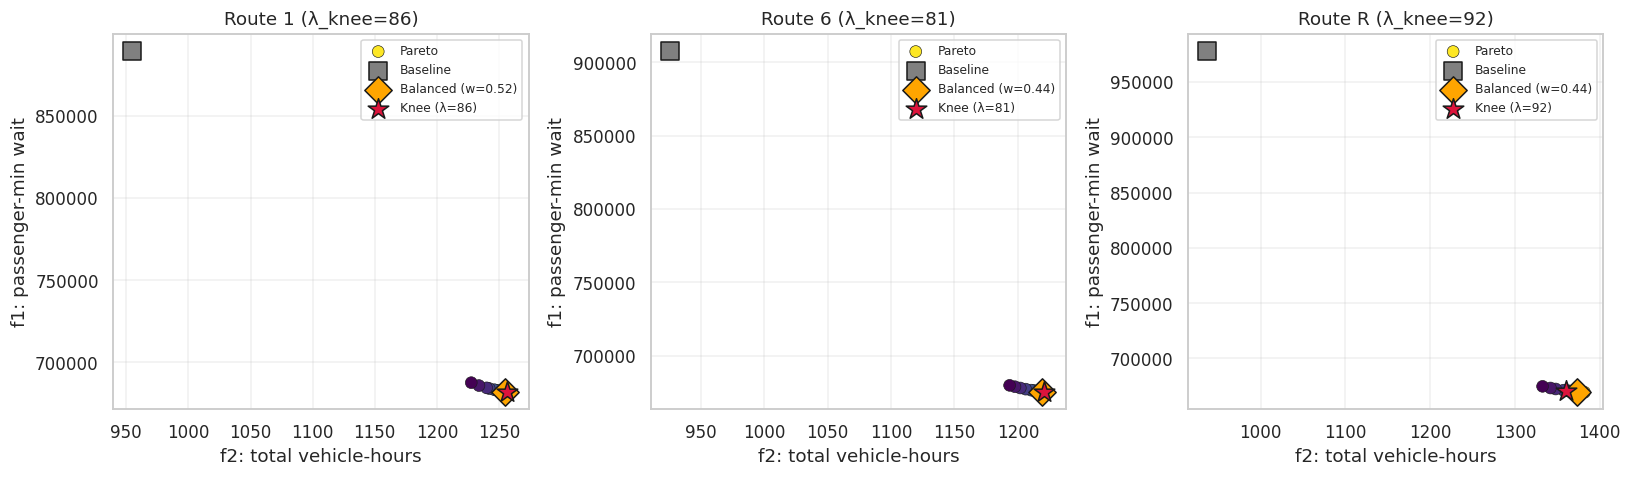

Đã lưu: /kaggle/working/outputs/default/fig_pareto_peak_routes.png


In [20]:
# §5b_per_route — Pareto frontier riêng cho từng route

lambda_knee_per_route: dict[str, float] = {}
pareto_dfs_per_route: dict[str, pd.DataFrame] = {}
pareto_summary_rows: list[dict] = []

_demand_peak = scenario_demand["weekday_peak"]


def make_opt_fn(tmin, tmax, cyc):
    def _opt(demand, lam):
        return srp.analytical_trips_per_slot(demand, lam, cyc, trips_min=tmin, trips_max=tmax)
    return _opt


def make_eval_fn(r_arr, d_arr, h_arr):
    def _eval(trips, demand, _lam_eval=None):
        return srp.compute_schedule_metrics(
            demand, trips,
            slot_route=r_arr, slot_dir=d_arr, slot_hour=h_arr,
            capacity_per_trip=float(CAPACITY_PER_TRIP),
            cycle_times=cycle_times,
        )
    return _eval


for r in OPT_ROUTES:
    mask_r = slot_route == r
    if mask_r.sum() == 0:
        continue

    demand_r = _demand_peak[mask_r]
    baseline_r = baseline_trips[mask_r]
    tmin_r = TRIPS_MIN[mask_r].copy()
    tmax_r = TRIPS_MAX[mask_r].copy()
    hour_r = slot_hour[mask_r]
    dir_r = slot_dir[mask_r]
    route_r = slot_route[mask_r]

    cyc_r = cycle_time_per_slot[mask_r]
    opt_fn_r = make_opt_fn(tmin_r, tmax_r, cyc_r)
    eval_fn_r = make_eval_fn(route_r, dir_r, hour_r)

    try:
        pareto_r = srp.generate_pareto_frontier(
            {"weekday_peak": demand_r},
            baseline_r,
            opt_fn_r,
            eval_fn_r,
            scenario="weekday_peak",
            n_points=PARETO_N_POINTS,
            lambda_eval=COST_PER_VEHICLE_HOUR,
        )
        knee_r = srp.find_knee_point(pareto_r)
        lam_knee = float(knee_r["lambda_equiv"])
        lambda_knee_per_route[r] = lam_knee
        pareto_dfs_per_route[r] = pareto_r

        pareto_summary_rows.append(dict(
            route_id=r,
            n_slots=int(mask_r.sum()),
            lambda_knee=lam_knee,
            f1_knee=float(knee_r["f1"]),
            f2_knee=float(knee_r["f2"]),
            total_trips_knee=float(knee_r["total_trips"]),
            f1_improve_pct=float(knee_r.get("f1_improve_pct", float("nan"))),
            f2_delta_pct=float(knee_r.get("f2_delta_pct", float("nan"))),
        ))
        print(f"  {r:4s} λ_knee={lam_knee:6.0f} | "
              f"f1_improve={knee_r.get('f1_improve_pct', float('nan')):+.1f}% "
              f"f2_delta={knee_r.get('f2_delta_pct', float('nan')):+.1f}%")

        base_m = eval_fn_r(baseline_r.astype(int), demand_r)
        srp.plot_pareto_frontier(
            pareto_r,
            baseline_f1=float(base_m["total_passenger_min_wait"]),
            baseline_f2=float(base_m["total_vehicle_hours"]),
            title=f"Pareto — route {r} (weekday_peak)",
            save_path=OUT_DIR / f"fig_pareto_{r}.png",
            annotate_all=False,
        )
        plt.close()
    except Exception as e:
        print(f"  [WARN] route {r}: Pareto failed ({e}) — fallback λ={LAMBDA_KNEE_FALLBACK}")
        lambda_knee_per_route[r] = float(LAMBDA_KNEE_FALLBACK)

pareto_per_route = pd.DataFrame(pareto_summary_rows)
pareto_per_route.to_csv(OUT_DIR / "pareto_per_route.csv", index=False)
if len(pareto_per_route):
    print(f"\nPareto per route: {len(pareto_per_route)} routes, "
          f"λ range [{pareto_per_route['lambda_knee'].min():.0f}, "
          f"{pareto_per_route['lambda_knee'].max():.0f}]")
print("Đã lưu:", OUT_DIR / "pareto_per_route.csv")

pareto_df = pareto_per_route.copy()
if len(pareto_per_route):
    _knee_s = pareto_per_route.loc[
        pareto_per_route["lambda_knee"].sub(_lambda_knee_median()).abs().idxmin()
    ]
    knee_row = srp.json_default(_knee_s)
else:
    knee_row = {}

# λ knee median — dùng cho §6 và báo cáo
if lambda_knee_per_route:
    print(f"λ reference (median knee) = {_lambda_knee_median():.0f}")

# Peak hub routes: overlay Pareto (1, 6, R)
PEAK_PARETO_ROUTES = ("1", "6", "R")
fig, axes = plt.subplots(1, len(PEAK_PARETO_ROUTES), figsize=(5 * len(PEAK_PARETO_ROUTES), 4.5))
if len(PEAK_PARETO_ROUTES) == 1:
    axes = [axes]
for ax, r in zip(axes, PEAK_PARETO_ROUTES):
    if r not in pareto_dfs_per_route:
        ax.set_title(f"Route {r} (no data)")
        continue
    pdf = pareto_dfs_per_route[r]
    mask_r = slot_route == r
    demand_r = _demand_peak[mask_r]
    baseline_r = baseline_trips[mask_r]
    hour_r = slot_hour[mask_r]
    dir_r = slot_dir[mask_r]
    route_r = slot_route[mask_r]
    _eval = make_eval_fn(route_r, dir_r, hour_r)
    base_m = _eval(baseline_r.astype(int), demand_r)
    srp.plot_pareto_frontier(
        pdf,
        baseline_f1=float(base_m["total_passenger_min_wait"]),
        baseline_f2=float(base_m["total_vehicle_hours"]),
        ax=ax,
        title=f"Route {r} (λ_knee={lambda_knee_per_route.get(r, float('nan')):.0f})",
        annotate_all=False,
    )
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_pareto_peak_routes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Đã lưu:", OUT_DIR / "fig_pareto_peak_routes.png")



## 6. Toi uu lich trinh

Dung analytical voi lambda theo tuyen.
Ap service window va cac rang buoc van hanh de tao lich toi uu.

In [21]:
service_windows = srp.build_route_direction_departure_windows(
    SCHEDULE_DIR, service_id=HEADWAY_SERVICE
)
service_windows.to_csv(OUT_DIR / "service_windows.csv", index=False)
print(f"GTFS service windows: {len(service_windows)} (route×direction)")
print(service_windows.head(8).to_string(index=False))

def optimize_schedule_constrained(
    demand: np.ndarray,
    lambda_cost: float | None = None,
    lambda_per_route: dict[str, float] | None = None,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    *,
    use_route_fleet: bool = True,
    use_capacity: bool = True,
    use_smoothness: bool = True,
) -> np.ndarray:
    """Analytical per-slot + service window + fleet/capacity/smoothness (§6)."""
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    lpr = lambda_per_route if lambda_per_route is not None else globals().get("lambda_knee_per_route")
    if lpr:
        raw = optimize_schedule_analytical_per_route(
            demand, lambda_per_route=lpr, trips_min=tmin, trips_max=tmax
        )
    else:
        raw = optimize_schedule_analytical(
            demand, lambda_cost=lambda_cost, trips_min=tmin, trips_max=tmax
        )
    t = srp.apply_service_window_constraints(
        raw,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        windows=service_windows,
        baseline_trips=baseline_trips,
        trips_min=tmin,
        trips_max=tmax,
    )
    return srp.apply_optimizer_constraints(
        t,
        demand,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        cycle_times=cycle_times,
        fleet_by_route_dir=fleet_by_route_dir,
        max_system_fleet=None,
        capacity_per_trip=CAPACITY_PER_TRIP,
        max_overflow_pct=MAX_OVERFLOW_PCT,
        smoothness_max_delta=SMOOTHNESS_MAX_DELTA,
        trips_min=tmin,
        trips_max=tmax,
        use_route_fleet=use_route_fleet,
        use_system_fleet=False,
        use_capacity=use_capacity,
        use_smoothness=use_smoothness,
    )


def resolve_lambda_for_demand_constrained(
    demand: np.ndarray,
    *,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> tuple[float, np.ndarray]:
    """Tối ưu với λ per-route (§5b knee); trả (λ median, lịch)."""
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    lpr = globals().get("lambda_knee_per_route") or {}
    lam_repr = float(np.median(list(lpr.values()))) if lpr else float(LAMBDA_KNEE_FALLBACK)
    sol = optimize_schedule_constrained(
        demand,
        lambda_per_route=lpr or None,
        lambda_cost=lam_repr if not lpr else None,
        trips_min=tmin,
        trips_max=tmax,
    )
    return lam_repr, sol



GTFS service windows: 58 (route×direction)
route_id  direction_id  first_dep_min  last_dep_min first_dep_time last_dep_time  first_hour  last_hour  n_trips
       1             0           74.5        1499.0       01:14:00      24:59:00           1          0      231
       1             1            6.5        1432.5       00:06:00      23:52:00           0         23      231
       2             0          153.5        1573.5       02:34:00      26:14:00           2          2      162
       2             1           19.0        1439.0       00:19:00      23:59:00           0         23      162
       3             0           45.5        1465.0       00:46:00      24:25:00           0          0      151
       3             1            4.5        1430.5       00:04:00      23:50:00           0         23      151
       4             0          107.0        1527.0       01:47:00      25:27:00           1          1      184
       4             1            7.5        1427.5  

In [22]:
opt_results = {}
lambda_used = {}
bound_status = {}
bound_by_hour = {}
import time

print(f"Optimizer: Analytical (per-route λ knee) | N_SLOTS={N_SLOTS}")
if lambda_knee_per_route:
    print(f"  λ knee median={_lambda_knee_median():.0f} | per-route range "
          f"[{min(lambda_knee_per_route.values()):.0f}, {max(lambda_knee_per_route.values()):.0f}]")

for scen, dem in scenario_demand.items():
    t0 = time.time()
    tmin, tmax = trips_bounds_for_scenario(scen)
    lam, opt_results[scen] = resolve_lambda_for_demand_constrained(
        dem, trips_min=tmin, trips_max=tmax,
    )
    bound_status[scen] = summarize_bound_status(
        opt_results[scen], label=f"{scen} final λ={lam:.0f}",
        trips_min=tmin, trips_max=tmax,
    )
    bound_by_hour[scen] = bound_status[scen]["by_hour_group"].to_dict(orient="records")
    lambda_used[scen] = {
        "median": float(lam),
        "per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()} if lambda_knee_per_route else None,
        "mode": "per_route" if lambda_knee_per_route and USE_PER_ROUTE_LAMBDA else "global",
    }
    m = evaluate_schedule(opt_results[scen], dem)
    base_wait = baseline_metrics[scen]["total_passenger_min_wait"]
    impr = pct_improve(base_wait, m["total_passenger_min_wait"])
    label = "Analytical"
    lam_label = (
        f"λ per-route (med={lam:.0f})"
        if lambda_knee_per_route and USE_PER_ROUTE_LAMBDA
        else f"λ={lam:.0f}"
    )
    util_str = (
        f" | fleet util={m['fleet_utilization']*100:.1f}%"
        if m.get("fleet_utilization") is not None
        else ""
    )
    print(f"[{scen:14s}] {label} wait={m['total_passenger_min_wait']:>14,.0f} (impr {impr:+.2f}%) "
          f"VH={m['total_vehicle_hours']:,.0f}{util_str} trips={m['total_trips']:.0f} {lam_label} [{time.time()-t0:.2f}s]")

_sched = pd.DataFrame({
    "route": slot_route, "direction": slot_dir, "hour": slot_hour,
    "baseline_trips": baseline_trips,
    "opt_trips": opt_results["weekday_peak"],
    "demand_pred": scenario_demand["weekday_peak"],
})
_sched = _sched.merge(
    service_windows.rename(columns={"route_id": "route", "direction_id": "direction"}),
    on=["route", "direction"], how="left",
)
_sched.to_csv(OUT_DIR / "schedule_weekday_peak.csv", index=False)
print("Đã lưu:", OUT_DIR / "schedule_weekday_peak.csv", "|", OUT_DIR / "service_windows.csv")




Optimizer: Analytical (per-route λ knee) | N_SLOTS=1104
  λ knee median=92 | per-route range [20, 420]
  [weekday_peak final λ=92] at TRIPS_MIN=1% | TRIPS_MAX=36% | interior=63% ✓ (target>60%)
    daytime    n= 769 | min=1% max=32% interior=67% ✓
    overnight  n= 335 | min=2% max=43% interior=55%
[weekday_peak  ] Analytical wait=    11,901,751 (impr +13.87%) VH=20,813 | fleet util=80.5% trips=9585 λ per-route (med=92) [0.23s]
  [weekend final λ=92] at TRIPS_MIN=2% | TRIPS_MAX=38% | interior=60% ✗ (target>60%)
    daytime    n= 769 | min=1% max=32% interior=67% ✓
    overnight  n= 335 | min=3% max=53% interior=44%
[weekend       ] Analytical wait=     8,140,178 (impr +15.77%) VH=20,922 | fleet util=80.9% trips=9604 λ per-route (med=92) [0.23s]
  [rainy_day final λ=92] at TRIPS_MIN=1% | TRIPS_MAX=34% | interior=64% ✓ (target>60%)
    daytime    n= 769 | min=1% max=29% interior=70% ✓
    overnight  n= 335 | min=2% max=47% interior=51%
[rainy_day     ] Analytical wait=    13,131,697 (impr

## 6b. Ablation rang buoc

So sanh tac dong cua tung nhom rang buoc tren `weekday_peak`.

In [23]:
def _pct_at_bound(trips_arr: np.ndarray, tmin: np.ndarray, tmax: np.ndarray) -> float:
  t = np.asarray(trips_arr, dtype=int)
  at_min = (t <= np.asarray(tmin, dtype=int)).mean()
  at_max = (t >= np.asarray(tmax, dtype=int)).mean()
  return float((at_min + at_max) * 100.0)


def _optimize_ablation_stage(
  demand: np.ndarray,
  lam: float,
  *,
  use_headway_bounds: bool,
  use_route_fleet: bool,
  use_capacity: bool,
  use_smoothness: bool,
) -> np.ndarray:
  tmin, tmax = TRIPS_MIN, TRIPS_MAX
  if not use_headway_bounds:
    tmin, tmax = _dyn_min, _dyn_max
  raw = optimize_schedule_analytical(demand, lambda_cost=lam, trips_min=tmin, trips_max=tmax)
  t = srp.apply_service_window_constraints(
    raw,
    slot_route=slot_route,
    slot_dir=slot_dir,
    slot_hour=slot_hour,
    windows=service_windows,
    baseline_trips=baseline_trips,
    trips_min=tmin,
    trips_max=tmax,
  )
  return srp.apply_optimizer_constraints(
    t,
    demand,
    slot_route=slot_route,
    slot_dir=slot_dir,
    slot_hour=slot_hour,
    cycle_times=cycle_times,
    fleet_by_route_dir=fleet_by_route_dir,
    max_system_fleet=None,
    capacity_per_trip=CAPACITY_PER_TRIP,
    max_overflow_pct=MAX_OVERFLOW_PCT,
    smoothness_max_delta=SMOOTHNESS_MAX_DELTA,
    trips_min=tmin,
    trips_max=tmax,
    use_route_fleet=use_route_fleet,
    use_system_fleet=False,
    use_capacity=use_capacity,
    use_smoothness=use_smoothness,
  )


_dem_ab = scenario_demand["weekday_peak"]
_lu_ab = lambda_used.get("weekday_peak", _lambda_knee_median())
_lam_ab = float(_lu_ab["median"] if isinstance(_lu_ab, dict) else _lu_ab)
_ablation_stages = [
  ("baseline (service_window only)", dict(use_headway_bounds=False, use_route_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ headway bounds", dict(use_headway_bounds=True, use_route_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ turnaround/fleet-per-RD", dict(use_headway_bounds=True, use_route_fleet=True, use_capacity=False, use_smoothness=False)),
  ("+ capacity floor", dict(use_headway_bounds=True, use_route_fleet=True, use_capacity=True, use_smoothness=False)),
  ("+ smoothness (full)", dict(use_headway_bounds=True, use_route_fleet=True, use_capacity=True, use_smoothness=True)),
]
_ab_rows = []
for label, flags in _ablation_stages:
  sol = _optimize_ablation_stage(_dem_ab, _lam_ab, **flags)
  tmin_ab, tmax_ab = (TRIPS_MIN, TRIPS_MAX) if flags["use_headway_bounds"] else (_dyn_min, _dyn_max)
  m = evaluate_schedule(sol, _dem_ab)
  _ab_rows.append(dict(
    stage=label,
    total_vehicle_hours=m["total_vehicle_hours"],
    total_passenger_min_wait=m["total_passenger_min_wait"],
    overflow_pct=m["overflow_pct"],
    max_queue_length=m["max_queue_length"],
    pct_at_bound=_pct_at_bound(sol, tmin_ab, tmax_ab),
  ))
constraint_ablation_df = pd.DataFrame(_ab_rows)
constraint_ablation_df.to_csv(OUT_DIR / "constraint_ablation_weekday_peak.csv", index=False)
print("=== Constraint ablation (weekday_peak) ===")
print(constraint_ablation_df.round(2).to_string(index=False))
print("Đã lưu:", OUT_DIR / "constraint_ablation_weekday_peak.csv")


=== Constraint ablation (weekday_peak) ===
                         stage  total_vehicle_hours  total_passenger_min_wait  overflow_pct  max_queue_length  pct_at_bound
baseline (service_window only)             22309.55               10931313.41          0.18           1434.07         67.12
              + headway bounds             22226.53               10980716.84          0.18           1434.07         69.02
     + turnaround/fleet-per-RD             20959.10               11777209.52          0.36           1434.07         42.30
              + capacity floor             20968.53               11746625.83          0.00              0.00         42.30
           + smoothness (full)             20776.25               11902005.24          0.18           1630.97         39.40
Đã lưu: /kaggle/working/outputs/default/constraint_ablation_weekday_peak.csv


### Rang buoc chinh

- Service window theo GTFS.
- Headway toi thieu / toi da.
- Fleet theo route-direction.
- Capacity floor theo nhu cau.
- Smoothness de han che nhay lich.

System fleet cap da bo; lambda chon theo tung tuyen.

## 7. Queue metrics

Bao cao cac chi so van hanh: thoi gian cho, overflow va vehicle-hours.

[baseline  ] wait=    13,818,522 pax-min | avg=3.57 min | VH=17,442 | overflow slots=0.9% | max queue=1,434 pax | fleet util=67.4%
[optimized ] wait=    11,901,751 pax-min | avg=3.07 min | VH=20,813 | overflow slots=0.2% | max queue=1,631 pax | fleet util=80.5%

Wait reduction: +13.87% | Vehicle-hours change: +19.32%


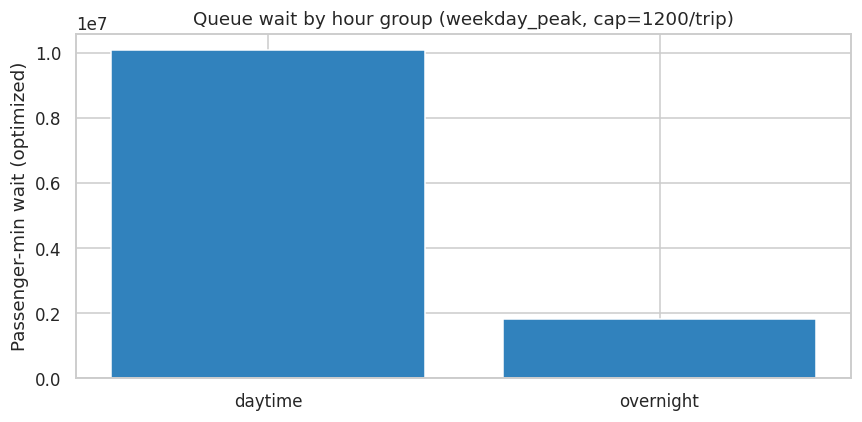

Đã lưu: /kaggle/working/outputs/default/wait_metric_comparison.csv


In [24]:
dem_peak = scenario_demand["weekday_peak"]
trips_opt = opt_results["weekday_peak"]

for label, trips_arr in [("baseline", baseline_trips), ("optimized", trips_opt)]:
    m = evaluate_schedule(trips_arr, dem_peak)
    print(
        f"[{label:10s}] wait={m['total_passenger_min_wait']:>14,.0f} pax-min | "
        f"avg={m['weighted_avg_wait_min']:.2f} min | VH={m['total_vehicle_hours']:,.0f} | "
        f"overflow slots={m['overflow_pct']:.1f}% | max queue={m['max_queue_length']:,.0f} pax"
        + (f" | fleet util={m['fleet_utilization']*100:.1f}%" if m.get('fleet_utilization') else "")
    )

m_base = evaluate_schedule(baseline_trips, dem_peak)
m_opt = evaluate_schedule(trips_opt, dem_peak)
wait_impr = pct_improve(m_base["total_passenger_min_wait"], m_opt["total_passenger_min_wait"])
vh_delta = (m_opt["total_vehicle_hours"] - m_base["total_vehicle_hours"]) / max(m_base["total_vehicle_hours"], 1e-9) * 100
print(f"\nWait reduction: {wait_impr:+.2f}% | Vehicle-hours change: {vh_delta:+.2f}%")

grp = srp.wait_totals_by_hour_groups(m_opt["slot_wait"], slot_hour)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(grp["hour_group"], grp["total_wait"], color="#3182bd")
ax.set_ylabel("Passenger-min wait (optimized)")
ax.set_title(f"Queue wait by hour group (weekday_peak, cap={CAPACITY_PER_TRIP}/trip)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_wait_metric_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

wait_metric_cmp = pd.DataFrame([
    dict(schedule="baseline", **{k: m_base[k] for k in (
        "total_passenger_min_wait", "weighted_avg_wait_min", "total_vehicle_hours",
        "overflow_pct", "total_overflow_pax", "max_queue_length",
    )}),
    dict(schedule="optimized", **{k: m_opt[k] for k in (
        "total_passenger_min_wait", "weighted_avg_wait_min", "total_vehicle_hours",
        "overflow_pct", "total_overflow_pax", "max_queue_length",
    )}),
])
wait_metric_cmp["wait_improve_pct"] = np.nan
wait_metric_cmp.loc[wait_metric_cmp["schedule"] == "optimized", "wait_improve_pct"] = wait_impr
wait_metric_cmp["vehicle_hours_delta_pct"] = np.nan
wait_metric_cmp.loc[wait_metric_cmp["schedule"] == "optimized", "vehicle_hours_delta_pct"] = vh_delta
if m_base.get("fleet_utilization") is not None:
    wait_metric_cmp["fleet_utilization_pct"] = [
        m_base.get("fleet_utilization", np.nan) * 100,
        m_opt.get("fleet_utilization", np.nan) * 100,
    ]
wait_metric_cmp.to_csv(OUT_DIR / "wait_metric_comparison.csv", index=False)
print("Đã lưu:", OUT_DIR / "wait_metric_comparison.csv")





## 8. Danh gia tong hop

So sanh baseline GTFS va lich toi uu theo tung kich ban.

In [25]:
rows = []
for scen in scenario_demand:
    dem = scenario_demand[scen]
    base_wait = baseline_metrics[scen]["total_passenger_min_wait"]
    method_sols = [("Baseline", baseline_trips), ("Analytical", opt_results[scen])]
    for method, sol in method_sols:
        m = evaluate_schedule(sol, dem)
        base_vh = baseline_metrics[scen]["total_vehicle_hours"]
        rows.append(dict(
            scenario=scen, method=method, n_slots=N_SLOTS,
            total_passenger_min_wait=m["total_passenger_min_wait"],
            total_vehicle_hours=m["total_vehicle_hours"],
            weighted_avg_wait_min=m["weighted_avg_wait_min"],
            headway_std=m["headway_std"],
            total_trips=m["total_trips"],
            overflow_pct=m["overflow_pct"],
            max_queue_length=m["max_queue_length"],
            wait_saved_vs_baseline=base_wait - m["total_passenger_min_wait"],
            vehicle_hours_delta_vs_baseline=m["total_vehicle_hours"] - base_vh,
            fleet_utilization=m.get("fleet_utilization"),
        ))

results_df = pd.DataFrame(rows)
base_vh_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["total_vehicle_hours"]
base_wait_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["total_passenger_min_wait"]
results_df["wait_improvement_pct"] = results_df.apply(
    lambda r: (base_wait_per_scen[r["scenario"]] - r["total_passenger_min_wait"]) / base_wait_per_scen[r["scenario"]] * 100, axis=1)
results_df["vehicle_hours_change_pct"] = results_df.apply(
    lambda r: (r["total_vehicle_hours"] - base_vh_per_scen[r["scenario"]]) / base_vh_per_scen[r["scenario"]] * 100, axis=1)
base_util_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["fleet_utilization"]
results_df["fleet_utilization_pct"] = results_df["fleet_utilization"] * 100.0
results_df["fleet_utilization_delta_pp"] = results_df.apply(
    lambda r: (float(r["fleet_utilization"] or 0) - float(base_util_per_scen.get(r["scenario"], 0) or 0)) * 100.0,
    axis=1,
)

def _lambda_used_label(scen):
    lu = lambda_used.get(scen, _lambda_knee_median())
    if isinstance(lu, dict):
        return f"per-route(med={lu.get('median', 0):.0f})"
    return f"{float(lu):.0f}"

_lam_note = ", ".join(f"{s}={_lambda_used_label(s)}" for s in scenario_demand)
print(f"=== Kết quả (Analytical, λ_tradeoff scan, λ_opt: {_lam_note}, {N_SLOTS} slots) ===")
print(results_df.round(3).to_string(index=False))
results_df.to_csv(OUT_DIR / "results_summary.csv", index=False)

tradeoff_df = results_df[results_df["method"] == "Analytical"]
tradeoff_show = tradeoff_df[[
    "scenario", "wait_saved_vs_baseline", "vehicle_hours_delta_vs_baseline",
    "wait_improvement_pct", "vehicle_hours_change_pct", "total_trips",
]].rename(columns={
    "wait_saved_vs_baseline": "passenger_min_wait_saved",
    "vehicle_hours_delta_vs_baseline": "vehicle_hours_increase",
})
print("\n=== Trade-off Analytical vs Baseline ===")
print(tradeoff_show.round(0).to_string(index=False))
tradeoff_show.to_csv(OUT_DIR / "tradeoff_summary.csv", index=False)

_bound_rows = [{"scenario": scen, **row} for scen, rows in bound_by_hour.items() for row in rows]
if _bound_rows:
    pd.DataFrame(_bound_rows).to_csv(OUT_DIR / "bound_by_hour.csv", index=False)
    print("Đã lưu:", OUT_DIR / "bound_by_hour.csv")


=== Kết quả (Analytical, λ_tradeoff scan, λ_opt: weekday_peak=per-route(med=92), weekend=per-route(med=92), rainy_day=per-route(med=92), 1104 slots) ===
    scenario     method  n_slots  total_passenger_min_wait  total_vehicle_hours  weighted_avg_wait_min  headway_std  total_trips  overflow_pct  max_queue_length  wait_saved_vs_baseline  vehicle_hours_delta_vs_baseline  fleet_utilization  wait_improvement_pct  vehicle_hours_change_pct  fleet_utilization_pct  fleet_utilization_delta_pp
weekday_peak   Baseline     1104              13818521.846            17442.300                  3.568        6.224       8124.0         0.906          1434.066                   0.000                            0.000              0.674                 0.000                     0.000                 67.450                       0.000
weekday_peak Analytical     1104              11901751.157            20812.517                  3.073        4.170       9585.0         0.181          1630.969             19

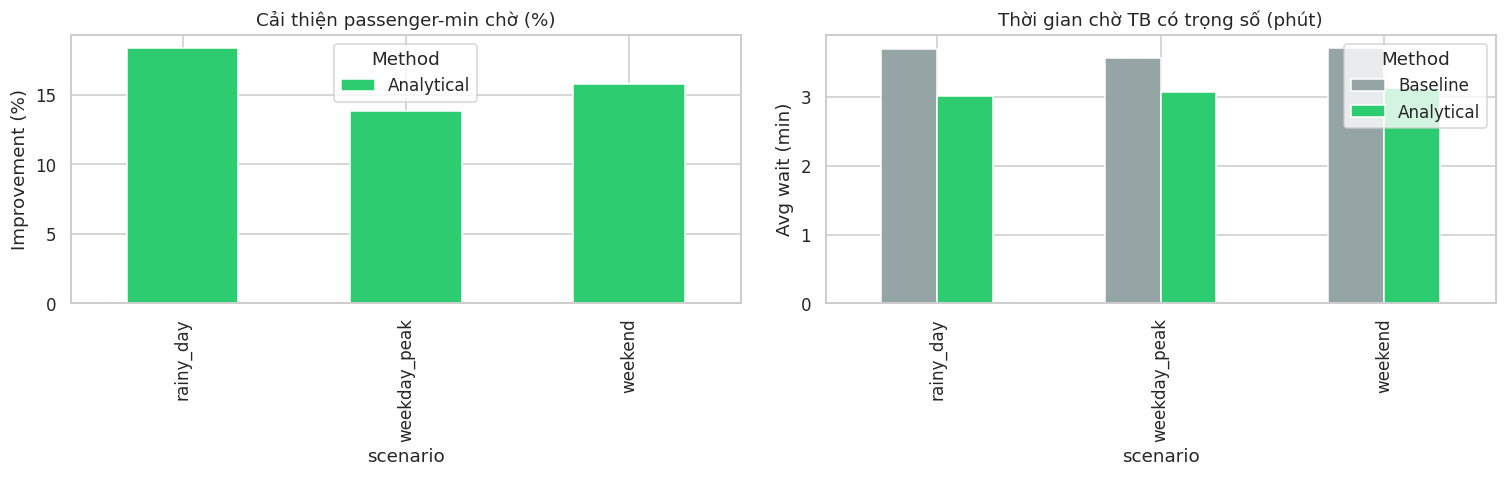

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

best_label = "Analytical"
methods_impr = [best_label]
pivot = results_df.pivot(index="scenario", columns="method", values="wait_improvement_pct")
pivot = pivot[[c for c in methods_impr if c in pivot.columns]]
pivot.plot(kind="bar", ax=axes[0], color=["#2ECC71"])
axes[0].set_title("Cải thiện passenger-min chờ (%)")
axes[0].set_ylabel("Improvement (%)"); axes[0].legend(title="Method")

cols_wait = ["Baseline", best_label]
pivot2 = results_df.pivot(index="scenario", columns="method", values="weighted_avg_wait_min")[cols_wait]
pivot2.plot(kind="bar", ax=axes[1], color=["#95A5A6", "#2ECC71"])
axes[1].set_title("Thời gian chờ TB có trọng số (phút)")
axes[1].set_ylabel("Avg wait (min)"); axes[1].legend(title="Method")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_improvement.png", dpi=120, bbox_inches="tight")
plt.show()


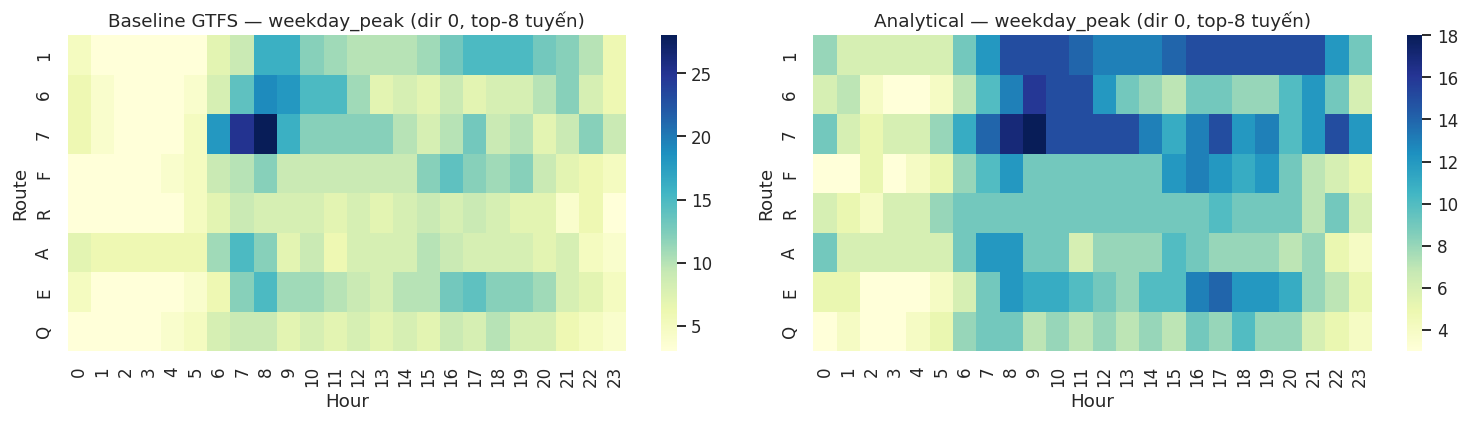

In [27]:
def reshape_trip_matrix(sol: np.ndarray, direction: int, routes: list) -> pd.DataFrame:
    sub = pd.DataFrame({
        "route": slot_route, "dir": slot_dir, "hour": slot_hour, "trips": sol
    })
    sub = sub[sub["dir"] == direction]
    return sub.pivot(index="route", columns="hour", values="trips").reindex(routes)

HEATMAP_ROUTES = [r for r in route_totals.index.astype(str) if r in set(OPT_ROUTES)][:8]
if not HEATMAP_ROUTES:
    HEATMAP_ROUTES = list(OPT_ROUTES)[:8]
scen_to_show = "weekday_peak"
best_label = "Analytical"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (method, sol) in zip(axes, [
    ("Baseline GTFS", baseline_trips),
    (best_label, opt_results[scen_to_show]),
]):
    m = reshape_trip_matrix(sol, direction=0, routes=HEATMAP_ROUTES)
    sns.heatmap(m, annot=False, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{method} — {scen_to_show} (dir 0, top-8 tuyến)")
    ax.set_xlabel("Hour"); ax.set_ylabel("Route")
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_schedule_{scen_to_show}.png", dpi=120, bbox_inches="tight")
plt.show()


In [28]:
summary_metrics = {
    "run_experiment": "default",
    "demand_model_type": DEMAND_MODEL_TYPE,
    "n_slots": int(N_SLOTS),
    "n_routes": int(len(OPT_ROUTES)),
    "n_hours": int(len(OPT_HOURS)),
    "routes": list(OPT_ROUTES),
    "opt_method": "Analytical",
    "n_headway_fallback": int(n_fallback),
    "scenarios": list(scenario_demand.keys()),
    "lambda_reference": float(_lambda_knee_median()),
    "cost_per_vehicle_hour": float(COST_PER_VEHICLE_HOUR),
    "lambda_opt": float(_lambda_knee_median()),
    "lambda_used": {
        k: (v["median"] if isinstance(v, dict) else float(v))
        for k, v in lambda_used.items()
    },
    "lambda_used_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
    "lambda_mode": "per_route" if USE_PER_ROUTE_LAMBDA and lambda_knee_per_route else "global",
    "fleet_utilization_denom": float(FLEET_UTILIZATION_DENOM),
    "system_fleet_capacity": float(FLEET_UTILIZATION_DENOM),  # legacy UI key
    "forecast_entity": "station",
    "n_stations": int(len(OPT_STATIONS)),
    "departure_time_projection": True,
    "bound_status": {s: srp.bound_status_jsonable(st) for s, st in bound_status.items()},
    "bound_by_hour": bound_by_hour if "bound_by_hour" in dir() else {},
    "lambda_candidates": sorted({float(v) for v in lambda_knee_per_route.values()}),
    "baseline": {s: baseline_metrics[s] for s in scenario_demand},
    "optimized": {s: evaluate_schedule(opt_results[s], scenario_demand[s])
                  for s in scenario_demand},
    "nn_eval": nn_eval_metrics,
    "lambda_knee_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
    "pareto_per_route_weekday_peak": pareto_per_route.to_dict(orient="records"),
    "pareto_knee_weekday_peak": knee_row,
}

srp.dump_json(OUT_DIR / "baseline_metrics.json", summary_metrics, indent=2)
print("Đã ghi:", OUT_DIR / "baseline_metrics.json")



Đã ghi: /kaggle/working/outputs/default/baseline_metrics.json


## 9. Export cho UI/API

Dong goi artifact de UI/API su dung truc tiep (khong re-train).
Thu muc dich: `outputs/default/ui_export/`.

In [29]:
import json
import joblib
import shutil
from datetime import datetime, timezone

UI_DIR = OUT_DIR / "ui_export"
UI_DIR.mkdir(parents=True, exist_ok=True)

# Đảm bảo blend weight đã tune trước khi export
tune_blend_weight_mlp()

# --- C1. Demand model artifacts ---
model.save(UI_DIR / "demand_model.keras")
joblib.dump(scaler, UI_DIR / "scaler.pkl")
if histgbm_model is not None:
    joblib.dump(histgbm_model, UI_DIR / "histgbm_blend.pkl")
if "quantile_models" in globals():
    joblib.dump(quantile_models, UI_DIR / "quantile_gbm_q75.pkl")

# --- C1b. Baseline lookup + inference bundle (API demand prediction) ---
baseline_lookup.reset_index().to_json(
    UI_DIR / "baseline_lookup.json", orient="records", indent=2, force_ascii=False
)
fallback.reset_index().to_json(
    UI_DIR / "fallback_baseline.json", orient="records", indent=2, force_ascii=False
)
srp.dump_json(UI_DIR / "lag_feature_defaults.json", lag_feature_defaults, indent=2)

_feature_med_cols = [c for c in NUM_FEATURES if c in df.columns and c != "log_baseline"]
feature_medians = {
    c: float(pd.to_numeric(df[c], errors="coerce").median()) for c in _feature_med_cols
}
srp.dump_json(UI_DIR / "feature_medians.json", feature_medians, indent=2)

_fb_station = df.groupby(["station_complex_id", "is_weekend"])["demand"].median().rename("fb_station_weekend")
_fb_hour = df.groupby(["hour", "is_weekend"])["demand"].median().rename("fb_hour_weekend")
_fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
if not np.isfinite(_fb_global) or _fb_global <= 0:
    _fb_global = 100.0

# Bundle suy diễn cấp GA + ma trận chiếu xuất bến (API: ga → projection → route×dir×hour)
demand_inference = {
    "scaler": scaler,
    "histgbm_model": histgbm_model,
    "blend_mlp_weight": float(blend_weight_mlp),
    "resid_clip": tuple(RESID_CLIP),
    "num_features": list(NUM_FEATURES),
    "forecast_entity": "station",
    "station_to_idx": {str(k): int(v) for k, v in station_to_idx.items()},
    "route_to_idx": {str(k): int(v) for k, v in station_to_idx.items()},  # alias: Keras input 'route_idx' = chỉ số GA
    "baseline_lookup": baseline_lookup,        # index (station_complex_id, hour, is_weekend)
    "fallback": fallback,                       # index (station_complex_id, hour)
    "lag_feature_defaults": lag_feature_defaults,  # keys "station|hour"
    "feature_medians": feature_medians,
    "fb_station_weekend": _fb_station,
    "fb_hour_weekend": _fb_hour,
    "fb_global": _fb_global,
    "use_route_embedding": bool(USE_STATION_EMBEDDING),
    "use_lag_features": bool(USE_LAG_FEATURES),
    "lag_feature_cols": list(LAG_FEATURE_COLS),
    "hourly_factor_cols": list(HOURLY_FACTOR_COLS),
    # --- Departure-Time Projection ---
    "station_rd_weights": station_rd_weights,
    "travel_offsets": travel_offsets,
    "board_minute": float(BOARD_MINUTE),
}
_impute_cols = ["month", "day_of_week", "is_weekend"] + [c for c in HOURLY_FACTOR_COLS if c in factors.columns]
factors[_impute_cols].drop_duplicates().to_parquet(UI_DIR / "scenario_impute_ref.parquet", index=False)
joblib.dump(demand_inference, UI_DIR / "demand_inference.pkl")

# --- C2. Route / station & slot metadata ---
route_meta = {
    "opt_routes": [str(r) for r in OPT_ROUTES],
    "opt_stations": [str(s) for s in OPT_STATIONS],
    "ridership_routes": [str(r) for r in RIDERSHIP_ROUTES],
    "missing_ridership_routes": [str(r) for r in MISSING_RIDERSHIP_ROUTES],
    "forecast_entity": "station",
    "station_to_idx": {str(k): int(v) for k, v in station_to_idx.items()},
    "route_to_idx": {str(k): int(v) for k, v in station_to_idx.items()},
    "route_dir_hours": {
        f"{r}|{d}": [int(h) for h in hs]
        for (r, d), hs in route_dir_hours.items()
    },
    "n_slots": int(N_SLOTS),
    "directions": [int(d) for d in DIRECTIONS],
    "opt_hours": [int(h) for h in OPT_HOURS],
}
srp.dump_json(UI_DIR / "route_meta.json", route_meta, indent=2)

# --- C3. Tunable config snapshot (UI form defaults) ---
ui_config = {
    "demand_model_type": DEMAND_MODEL_TYPE,

    "resid_clip": float(RESID_CLIP[1]),
    "blend_mlp_weight": float(blend_weight_mlp),
    "lambda_opt": float(_lambda_knee_median()),
    "lambda_reference": float(_lambda_knee_median()),
    "lambda_knee_fallback": float(LAMBDA_KNEE_FALLBACK),
    "cost_per_vehicle_hour": float(COST_PER_VEHICLE_HOUR),
    "lambda_cost_eval": float(COST_PER_VEHICLE_HOUR),
    "lambda_knee_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
    "use_per_route_lambda": bool(USE_PER_ROUTE_LAMBDA),
    "fleet_utilization_denom": float(FLEET_UTILIZATION_DENOM),
    "system_fleet_capacity": float(FLEET_UTILIZATION_DENOM),  # legacy UI key
    "trips_daytime_max_factor": float(TRIPS_DAYTIME_MAX_FACTOR),
    "trips_overnight_max_factor": float(TRIPS_OVERNIGHT_MAX_FACTOR),
    "trips_min_factor": float(TRIPS_MIN_FACTOR),
    "trips_overnight_min_factor": float(TRIPS_OVERNIGHT_MIN_FACTOR),
    "risk_scenarios": list(RISK_SCENARIOS),
    "risk_demand_quantile": float(RISK_DEMAND_QUANTILE),
    "trips_max_delta": int(TRIPS_MAX_DELTA),
    "min_headway_min": float(MIN_HEADWAY_MIN),
    "max_headway_min": float(MAX_HEADWAY_MIN),
    "turnaround_buffer_min": float(TURNAROUND_BUFFER_MIN),
    "max_overflow_pct": float(MAX_OVERFLOW_PCT),
    "smoothness_max_delta": int(SMOOTHNESS_MAX_DELTA),
    "rainy_peak_trips_min_factor": float(RAINY_PEAK_TRIPS_MIN_FACTOR),
    "overnight_max_headway_min": float(OVERNIGHT_MAX_HEADWAY_MIN),
    "rainy_daytime_max_factor": float(RAINY_DAYTIME_MAX_FACTOR),
    "scenarios": list(SCENARIOS),
    "rainy_hour_boost": {str(k): float(v) for k, v in RAINY_HOUR_BOOST.items()},
    "num_features": list(NUM_FEATURES),
    "lag_feature_cols": list(LAG_FEATURE_COLS),
    "nn_hidden": list(NN_HIDDEN),
    "capacity_per_trip": int(CAPACITY_PER_TRIP),
    "use_route_embedding": bool(USE_STATION_EMBEDDING),
    "forecast_entity": "station",
    "departure_time_projection": True,
    "station_embedding_dim": int(STATION_EMBEDDING_DIM),
    "overnight_demand_percentile": float(OVERNIGHT_DEMAND_PERCENTILE),
    "board_minute": float(BOARD_MINUTE),
}
srp.dump_json(UI_DIR / "ui_config.json", ui_config, indent=2)

# --- C4. Optimizer replay state ---
joblib.dump(
    {
        "baseline_trips": baseline_trips,
        "TRIPS_MIN": TRIPS_MIN,
        "TRIPS_MAX": TRIPS_MAX,
        "slot_route": slot_route,
        "slot_dir": slot_dir,
        "slot_hour": slot_hour,
        "daytime_slot_mask": DAYTIME_SLOT_MASK,
        "baseline_lookup": baseline_lookup,
        "fallback": fallback,
        "lag_feature_defaults": lag_feature_defaults,
        "fb_station_weekend": _fb_station,
        "fb_hour_weekend": _fb_hour,
        "fb_global": _fb_global,
        "service_windows": service_windows,
        "cycle_times": cycle_times,
        "fleet_by_route_dir": fleet_by_route_dir,
        "fleet_utilization_denom": float(FLEET_UTILIZATION_DENOM),
        "system_fleet_capacity": float(FLEET_UTILIZATION_DENOM),  # legacy UI key
        "lambda_knee_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
        "scenario_demand": {s: scenario_demand[s] for s in SCENARIOS},
        # --- Departure-Time Projection (cho API tái dựng cầu route×dir×hour từ ga) ---
        "station_rd_weights": station_rd_weights,
        "travel_offsets": travel_offsets,
        "station_to_idx": {str(k): int(v) for k, v in station_to_idx.items()},
        "scenario_station_demand": {s: scenario_station_demand[s] for s in SCENARIOS},
        "board_minute": float(BOARD_MINUTE),
    },
    UI_DIR / "optimizer_state.pkl",
)

# --- C5. Pareto per-route ---
pareto_per_route.to_json(UI_DIR / "pareto_per_route.json", orient="records", indent=2, force_ascii=False)
srp.dump_json(UI_DIR / "pareto_knee.json", knee_row, indent=2)

# --- C6. Optimized schedules per scenario ---
for scen in SCENARIOS:
    tmin, tmax = trips_bounds_for_scenario(scen)
    sched = pd.DataFrame({
        "route": slot_route,
        "direction": slot_dir,
        "hour": slot_hour,
        "baseline_trips": baseline_trips,
        "opt_trips": opt_results[scen],
        "demand_pred": scenario_demand[scen],
        "trips_min": tmin,
        "trips_max": tmax,
        "at_max": (opt_results[scen] >= tmax).astype(int),
    })
    sched.to_json(UI_DIR / f"schedule_{scen}.json", orient="records", indent=2, force_ascii=False)

# --- C9. Run metrics snapshot + copy full baseline_metrics ---
run_metrics = {
    "exported_at": datetime.now(timezone.utc).isoformat(),
    "out_dir": str(OUT_DIR),
    "lambda_used": {
        k: (v["median"] if isinstance(v, dict) else float(v))
        for k, v in lambda_used.items()
    },
    "lambda_used_detail": lambda_used,
    "fleet_utilization_denom": float(FLEET_UTILIZATION_DENOM),
    "system_fleet_capacity": float(FLEET_UTILIZATION_DENOM),  # legacy UI key
    "bound_status": {s: srp.bound_status_jsonable(st) for s, st in bound_status.items()},
    "bound_by_hour": bound_by_hour,
    "optimized": summary_metrics["optimized"],
    "baseline": summary_metrics["baseline"],
    "pareto_knee": knee_row,
}
srp.dump_json(UI_DIR / "run_metrics.json", run_metrics, indent=2)

_src_bm = OUT_DIR / "baseline_metrics.json"
if _src_bm.exists():
    shutil.copy(_src_bm, UI_DIR / "baseline_metrics.json")

manifest = {
    "exported_at": run_metrics["exported_at"],
    "ui_dir": str(UI_DIR),
    "files": sorted(p.name for p in UI_DIR.iterdir() if p.is_file()),
}
srp.dump_json(UI_DIR / "manifest.json", manifest, indent=2)

print(f"✓ UI export → {UI_DIR.resolve()}")
print(f"  {len(manifest['files'])} files:", ", ".join(manifest["files"]))



✓ UI export → /kaggle/working/outputs/default/ui_export
  19 files: baseline_lookup.json, baseline_metrics.json, demand_inference.pkl, demand_model.keras, fallback_baseline.json, feature_medians.json, histgbm_blend.pkl, lag_feature_defaults.json, optimizer_state.pkl, pareto_knee.json, pareto_per_route.json, quantile_gbm_q75.pkl, route_meta.json, run_metrics.json, scaler.pkl, schedule_rainy_day.json, schedule_weekday_peak.json, schedule_weekend.json, ui_config.json


## 10. Lich ga va mo phong tre

Demo lich den ga, fleet sweep-line va kich ban truyen tre.
Phan nay khong thay doi toi uu chinh.

Lịch chi tiết route 1: 39299 dòng (trip × ga), 24 trips

Fleet — trung bình underestimate của lower bound: -5.9%
route_id  direction_id  fleet_lower_bound  fleet_continuous  pct_underestimate
      FS             1               2.30               3.0              23.33
       H             1               2.33               3.0              22.23
       H             0               2.33               3.0              22.23
      FS             0               2.40               3.0              20.00
       G             0              10.53              11.0               4.24

[Demo] Trip 13 trễ 5 phút tại stop_sequence=18:
  Trip bị ảnh hưởng: 1 | Tổng hold: 357.5 phút | Max hold 1 trip: 5.0 phút


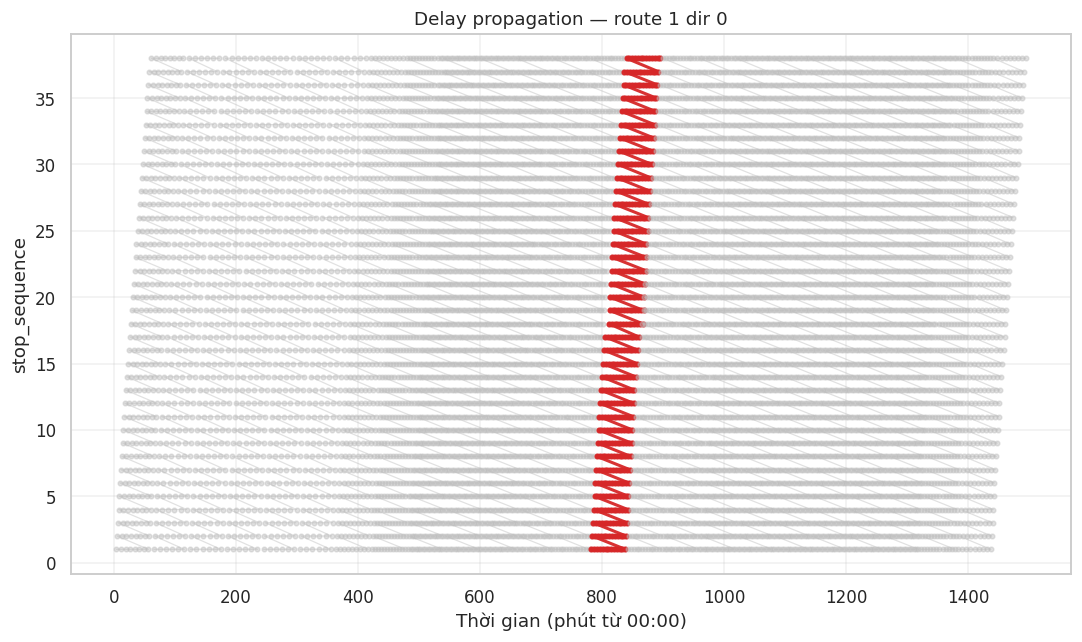

Đã lưu §10: /kaggle/working/outputs/default/station_schedule_1.csv | /kaggle/working/outputs/default/fleet_estimate_comparison.csv | /kaggle/working/outputs/default/delay_simulation_1.csv


In [30]:
import importlib
importlib.reload(srp)

# --- 11a. Build lịch chi tiết đến ga cho 1 route demo ---
demo_route = OPT_ROUTES[0]
offset_templates = srp.load_gtfs_stop_offset_templates(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)

demo_station_schedule = srp.build_station_schedule_for_route(
    opt_results["weekday_peak"],
    slot_route, slot_dir, slot_hour,
    SCHEDULE_DIR, demo_route, offset_templates=offset_templates,
)
demo_station_schedule = srp.assign_trip_ids(demo_station_schedule)
print(
    f"Lịch chi tiết route {demo_route}: {len(demo_station_schedule)} dòng "
    f"(trip × ga), {demo_station_schedule['trip_id'].nunique()} trips"
)
demo_station_schedule.to_csv(OUT_DIR / f"station_schedule_{demo_route}.csv", index=False)

# --- 11b. Fleet chính xác cho toàn mạng ---
fleet_comparison = srp.compare_fleet_estimates(
    baseline_trips, slot_route, slot_dir, slot_hour, cycle_times
)
fleet_comparison.to_csv(OUT_DIR / "fleet_estimate_comparison.csv", index=False)
print(
    f"\nFleet — trung bình underestimate của lower bound: "
    f"{fleet_comparison['pct_underestimate'].mean():.1f}%"
)
print(
    fleet_comparison.sort_values("pct_underestimate", ascending=False)
    .head(5).round(2).to_string(index=False)
)

# --- 11c. Mô phỏng trễ (what-if demo) trên lịch route đã build ở 11a ---
_demo_dir = int(demo_station_schedule["direction"].iloc[0])
_demo_trip = int(demo_station_schedule["trip_id"].median())
_demo_stop_seq = int(
    demo_station_schedule.loc[
        demo_station_schedule["trip_id"] == _demo_trip, "stop_sequence"
    ].median()
)

adjusted = srp.simulate_delay_propagation(
    demo_station_schedule,
    route_id=demo_route,
    direction_id=_demo_dir,
    delayed_trip_id=_demo_trip,
    delay_min=5.0,
    delay_at_stop_sequence=_demo_stop_seq,
    min_headway_ratio=0.6,
    max_propagation_trips=3,
    dwell_recovery_min=0.5,
)
impact = srp.summarize_delay_impact(adjusted)
print(f"\n[Demo] Trip {_demo_trip} trễ 5 phút tại stop_sequence={_demo_stop_seq}:")
print(
    f"  Trip bị ảnh hưởng: {impact['n_trips_affected']} | "
    f"Tổng hold: {impact['total_hold_min']:.1f} phút | "
    f"Max hold 1 trip: {impact['max_hold_min']:.1f} phút"
)

srp.plot_delay_propagation(
    adjusted, route_id=demo_route, direction_id=_demo_dir,
    title=f"Delay propagation — route {demo_route} dir {_demo_dir}",
    save_path=OUT_DIR / f"fig_delay_propagation_{demo_route}.png",
)
plt.show()
adjusted.to_csv(OUT_DIR / f"delay_simulation_{demo_route}.csv", index=False)
print(
    "Đã lưu §10:", OUT_DIR / f"station_schedule_{demo_route}.csv", "|",
    OUT_DIR / "fleet_estimate_comparison.csv", "|",
    OUT_DIR / f"delay_simulation_{demo_route}.csv",
)

## 11. Ket luan

- Demand du bao on dinh voi mo hinh lai.
- Lich toi uu giam cho va giu chi phi hop ly.
- Lambda duoc chon theo tung tuyen qua Pareto.
- Co the trien khai nhanh qua artifact o phan export.